# 07 — Criteo: the experiment that shows risk-targeting is not uplift-targeting

06 shipped a risk model. It is honest about being weak — test AP 0.1809 against a 0.1165
base rate, ROC-AUC 0.6278, a top decile that repeats at 21.93% for a lift of 1.88× — but
it works, and it ranks 91,334 users by how likely they are to buy again. The obvious next
move is to point the bottom of that ranking at a retention campaign.

**That move is wrong, and this notebook is where it gets proved wrong on real randomised
data.** A propensity score ranks who is *likely* to do something. A campaign needs to know
who would *respond* to being contacted. Those are different orderings, and nothing in
REES46 can separate them, because REES46 contains no randomisation (CLAUDE.md principle
10). Criteo's uplift dataset does: 13,979,592 users randomised 85/15 to an advertising
treatment, with visit, conversion and exposure recorded (principle 11).

### What this notebook concludes, stated up front

1. **The randomisation is real but the published file is not perfectly balanced.** SRM
   passes at χ² = 1.8e-06 — the treated count misses 85.000% by 1.8 users, so the split is
   effectively deterministic rather than Bernoulli. All twelve covariates clear the
   conventional |SMD| < 0.1 bar (max 0.0488 on `f3`), *but* the SMDs are 7–65× larger than
   the ±0.00075 sampling noise an 85/15 draw at this n would produce, and a LightGBM
   propensity model separates the arms at test AUC 0.5105. **This was expected to be
   cosmetic and is not:** three covariate adjustments with different functional forms all
   move the ATE downward, by 13–32% (§3C), so every Criteo magnitude here carries a bias
   band on top of the transfer caveat.
2. **The ITT is large and precisely estimated.** Visit +1.034 pp [+1.006, +1.063], a
   +27.07% relative lift. Conversion +0.1152 pp [+0.1085, +0.1219], +59.45% relative.
3. **Conditioning on exposure inflates the complier effect by 62%.** Exposure is
   post-randomisation and one-sided (no control user is ever exposed). The Bloom/Wald TOT
   is +3.196 pp [+3.009, +3.383] on conversion; the naive exposed-versus-control contrast
   reports +5.185 pp. Same structural error as the Cookie Cats gate-40 analysis.
4. **Uplift models must be scored with Qini, not accuracy.** The T-learner is built from a
   response model that predicts conversion at ROC-AUC 0.9590, and the difference of two
   such models ranks uplift *worse* than the response model it was built from. Accuracy
   and uplift are not the same quantity and are not monotonically related.
5. **THE EXPECTED RESULT ONLY HALF HELD, AND THE HALF THAT FAILED IS THE INTERESTING
   ONE.** Uplift targeting does capture most of the effect at half the cost — top-50% by
   T-learner τ̂ captures 83.8% of the total incremental conversions, 94.4% by X-learner τ̂.
   But it did **not** beat a plain baseline-response ranking, which captured 97.4% with a
   Qini ratio of 0.8214 against the T-learner's 0.5933 (paired ΔQini −0.228,
   CI [−0.298, −0.159]). At a 0.29% conversion rate the uplift signal is drowned; §6E
   shows on `visit`, where events are 16× more plentiful, that the ordering flips back
   (ΔQini +0.036, CI [+0.002, +0.069]).
6. **Risk targeting does not "perform close to random". It performs far worse than
   random.** Targeting the bottom 50% of baseline propensity — the exact operation of
   pointing 06's model at its high-churn-risk tail — captured 81 of 7,743 available
   incremental conversions, 1.0%, against random-50%'s 49.8%. Qini ratio −0.9006.
7. **Therefore 08 is a design, not a targeting rule.** The direction that wins here is an
   empirical property of *this* mechanism. It cannot be read off REES46 and it cannot be
   assumed to transfer. That is the whole argument for randomising.

### Three honesty constraints, binding on every sentence below

- Criteo is display advertising with a multi-day window. REES46 is cosmetics e-commerce
  with a 30-day repeat horizon. **The mechanism transfers; the effect sizes do not.** No
  number in §2–§7 is a forecast for REES46.
- The file has no user id and no timestamp, one row per randomised user. **No retention
  curve, no cadence, no lifecycle analysis is possible here** and none is attempted.
- `f0`–`f11` are randomly projected and uninterpretable. **Uplift heterogeneity can be
  measured but not explained.** Where a section would normally say *why* a segment
  responds, this one says that it cannot.

---

## §0 — Dataset registration: 07 certifies its own input

`handoff_params.json` is the chain's contract, and the rule is that a notebook may only
read a key some **upstream notebook wrote**. `criteo_dataset` broke that rule: it was
written by a script run outside the chain, so it survived in the committed JSON and
nothing noticed — until a clean run deleted the artefacts, rebuilt the file from 00
onwards, and 07 died on `KeyError: 'criteo_dataset'` four seconds in.

This section is the fix. Nothing above it reads the key; it fingerprints the file, checks
every property that Criteo publishes, and **writes `criteo_dataset` itself**. The rest of
the notebook then inherits it exactly as before. A key with no writer in the chain is a
key that only exists because nobody has run the chain from scratch.

One honesty note on the fingerprint: Criteo publishes the row count, the schema, the
split and the outcome rates, but **not a digest**. The sha256 below is therefore
*recorded*, not *verified* — it pins the bytes for future runs and for anyone
re-downloading the file. It is labelled that way in the table and in the JSON.


In [1]:
# =======================================================================================
# CRITEO DATASET REGISTRATION -- the writer for handoff["criteo_dataset"].
# Self-contained on purpose: this cell runs BEFORE the notebook's own bootstrap, because
# nothing may read the key before its writer has run.
# =======================================================================================
import os, sys, json, time, hashlib
import duckdb

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

CRITEO_PATH = os.path.join("data", "raw", "criteo", "criteo-research-uplift-v2.1.csv.gz")

# ---- What Criteo publishes for criteo-uplift v2.1. These are the reference values; every
# ---- one of them is checked against the bytes on disk below. Rates are published to the
# ---- precision shown, so each carries the tolerance that precision implies.
SPEC = {
    "bytes":      311_422_618,   # content-length of the published .csv.gz
    "rows":       13_979_592,
    "columns":    [f"f{i}" for i in range(12)] + ["treatment", "conversion", "visit", "exposure"],
    "treatment_ratio": (0.85,   0.001),
    "visit_rate":      (0.047,  0.001),
    "conversion_rate": (0.0029, 0.0002),
    "exposure_rate":   (0.0306, 0.001),
}

print("CRITEO DATASET REGISTRATION")
print("=" * 100)
if not os.path.exists(CRITEO_PATH):
    raise FileNotFoundError(
        f"{CRITEO_PATH} not found. 07 is the only notebook that uses it; see README for the "
        "download URL recorded in handoff['criteo_dataset']['source_url'].")

t0 = time.time()
_h = hashlib.sha256()
with open(CRITEO_PATH, "rb") as fh:
    for chunk in iter(lambda: fh.read(1 << 22), b""):
        _h.update(chunk)
SHA256 = _h.hexdigest()
NBYTES = os.path.getsize(CRITEO_PATH)
print(f"sha256 {SHA256}  ({time.time()-t0:.1f}s over {NBYTES:,} bytes)")

# Aggregates only -- one scan of the gz, no 14M-row frame materialised here. Section 2
# loads the full table for the analysis; this cell only has to certify the file.
_con = duckdb.connect()
_con.execute("SET enable_progress_bar=false")
COLUMNS = [r[0] for r in _con.execute(
    f"DESCRIBE SELECT * FROM read_csv_auto('{CRITEO_PATH}')").fetchall()]
t0 = time.time()
m = _con.execute(f"""
    SELECT count(*) AS rows,
           sum(treatment)::BIGINT          AS n_treated,
           (count(*) - sum(treatment))::BIGINT AS n_control,
           avg(treatment)                  AS treatment_ratio,
           avg(visit)                      AS visit_rate,
           avg(conversion)                 AS conversion_rate,
           avg(exposure)                   AS exposure_rate,
           avg(CASE WHEN treatment=1 THEN visit END)
             - avg(CASE WHEN treatment=0 THEN visit END)      AS naive_ate_visit,
           avg(CASE WHEN treatment=1 THEN conversion END)
             - avg(CASE WHEN treatment=0 THEN conversion END) AS naive_ate_conversion
    FROM read_csv_auto('{CRITEO_PATH}')
""").fetchdf().iloc[0]
_con.close()
print(f"single aggregate scan: {time.time()-t0:.1f}s")

CHECKS = []
def _chk(name, ok, published, measured):
    CHECKS.append(dict(check=name, published=str(published), measured=str(measured),
                       passed=bool(ok)))
    return bool(ok)

def _near(name, key, measured):
    exp, tol = SPEC[key]
    return _chk(name, abs(float(measured) - exp) <= tol, f"{exp} +/- {tol}", f"{float(measured):.6f}")

_chk("file size (bytes)",        NBYTES == SPEC["bytes"],        f"{SPEC['bytes']:,}", f"{NBYTES:,}")
_chk("row count",                int(m["rows"]) == SPEC["rows"], f"{SPEC['rows']:,}",  f"{int(m['rows']):,}")
_chk("schema (names and order)", COLUMNS == SPEC["columns"],
     "f0-f11, treatment, conversion, visit, exposure", ", ".join(COLUMNS))
_near("treatment ratio", "treatment_ratio", m["treatment_ratio"])
_near("visit rate",      "visit_rate",      m["visit_rate"])
_near("conversion rate", "conversion_rate", m["conversion_rate"])
_near("exposure rate",   "exposure_rate",   m["exposure_rate"])
_chk("sha256", True, "not published by Criteo -- RECORDED, not verified", SHA256[:16] + "...")

import pandas as _pd
_reg = _pd.DataFrame(CHECKS)
print()
print(_reg.to_string(index=False))
_failed = _reg.loc[~_reg.passed, "check"].tolist()
assert not _failed, (
    f"Criteo file does not match the published spec on: {_failed}. Every number in this "
    "notebook would be measuring a different dataset. Re-download before continuing.")
print(f"\nAll {len(_reg)} registration checks pass. Writing handoff['criteo_dataset'].")

_HANDOFF_PATH = os.path.join("outputs", "handoff_params.json")
with open(_HANDOFF_PATH) as f:
    _handoff = json.load(f)

_handoff["criteo_dataset"] = {
    "present": True,
    "path": CRITEO_PATH.replace(os.sep, "/"),
    "bytes": int(NBYTES),
    "sha256": SHA256,
    "sha256_status": "RECORDED, NOT VERIFIED -- Criteo publishes no digest for this file. It pins the "
                     "bytes for later runs; it is not evidence of provenance.",
    "rows": int(m["rows"]),
    "columns": COLUMNS,
    "schema_note": "f0-f11 dense float features (anonymised); treatment 1/0; visit, conversion, "
                   "exposure binary outcomes. No user id and no timestamp -- one row per randomised user.",
    "randomisation": {"treatment_ratio": round(float(m["treatment_ratio"]), 6),
                      "n_treated": int(m["n_treated"]), "n_control": int(m["n_control"])},
    "outcome_rates": {"visit_rate": round(float(m["visit_rate"]), 6),
                      "conversion_rate": round(float(m["conversion_rate"]), 6),
                      "exposure_rate": round(float(m["exposure_rate"]), 6)},
    "naive_ate_unvalidated": {
        "visit": round(float(m["naive_ate_visit"]), 6),
        "conversion": round(float(m["naive_ate_conversion"]), 6),
        "warning": "Raw difference in means, computed here ONLY to confirm the file is usable and to "
                   "give Section 7's self-check something to reproduce independently. It is NOT a "
                   "result: Sections 2-3 derive the ATE properly with SRM and covariate-balance "
                   "checks, CIs, and ITT vs TOT (exposure is post-randomisation and one-sided).",
    },
    "verified_against_published_spec": True,
    "registration_checks": CHECKS,
    "verified_by": "07_criteo_experiment.ipynb Section 0, at the top of the notebook, before any read "
                   "of this key. It was previously written by a script run OUTSIDE the notebook "
                   "chain, which is why a clean 00->08 run failed here with KeyError.",
    "source_url": "https://criteostorage.blob.core.windows.net/criteo-research-datasets/"
                  "criteo-uplift-v2.1.csv.gz",
    "source_note": "Criteo AI Lab's own Azure mirror. The canonical go.criteo.net link now 404s; a "
                   "Hugging Face mirror (datasets/criteo/criteo-uplift) serves a byte-identical file "
                   "(same 311,422,618-byte content-length).",
    "why_it_is_here": "REES46 has no randomised experiment (principle 10). Criteo is the genuine one "
                      "(principle 11) and is what lets 07 show that risk-targeting != uplift-targeting.",
}
with open(_HANDOFF_PATH, "w") as f:
    json.dump(_handoff, f, indent=2, default=str)
print(f"handoff['criteo_dataset'] written to {_HANDOFF_PATH} by this notebook.")


CRITEO DATASET REGISTRATION


sha256 2716e1bf0fd157a93b5bf86924d9088419dfbac2022c6cd90030220634f616dc  (0.3s over 311,422,618 bytes)


single aggregate scan: 7.0s

                   check                                         published                                                                                 measured  passed
       file size (bytes)                                       311,422,618                                                                              311,422,618    True
               row count                                        13,979,592                                                                               13,979,592    True
schema (names and order)    f0-f11, treatment, conversion, visit, exposure f0, f1, f2, f3, f4, f5, f6, f7, f8, f9, f10, f11, treatment, conversion, visit, exposure    True
         treatment ratio                                    0.85 +/- 0.001                                                                                 0.850000    True
              visit rate                                   0.047 +/- 0.001                                     

In [2]:
import os, sys, json, time, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.metrics import roc_auc_score

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from src.plotting import frame, add_title, add_takeaway, save, show_df, thousands
from src.data import connect

SEED = 42
np.random.seed(SEED)
TABLES_DIR    = os.path.join("outputs", "tables")
FIG_DIR       = os.path.join("outputs", "figures")
PROCESSED_DIR = os.path.join("data", "processed")
for d in (TABLES_DIR, FIG_DIR, PROCESSED_DIR):
    os.makedirs(d, exist_ok=True)

with open(os.path.join("outputs", "handoff_params.json")) as f:
    handoff = json.load(f)

CR    = handoff["criteo_dataset"]
MOD   = handoff["modelling"]
CHURN = handoff["churn_definition"]

print("INHERITED FROM handoff_params.json -- criteo_dataset from Section 0 above, the rest upstream")
print("=" * 100)
print(f"  criteo file        : {CR['path']}")
print(f"  declared rows      : {CR['rows']:,}   bytes {CR['bytes']:,}")
print(f"  declared ratio     : {CR['randomisation']['treatment_ratio']}  "
      f"(T {CR['randomisation']['n_treated']:,} / C {CR['randomisation']['n_control']:,})")
print(f"  declared rates     : visit {CR['outcome_rates']['visit_rate']:.6f}  "
      f"conversion {CR['outcome_rates']['conversion_rate']:.6f}  exposure {CR['outcome_rates']['exposure_rate']:.6f}")
print(f"  06 shipped model   : test AP {MOD['shipped_model']['test_AP']}  "
      f"ROC {MOD['shipped_model']['test_ROC_AUC']}  decile-1 lift {MOD['shipped_model']['decile1_lift']}")
print()
print("THE NAIVE ATE REGISTERED IN SECTION 0 IS NOT A RESULT. Verbatim warning it carries:")
print("=" * 100)
import textwrap
print(textwrap.fill(CR["naive_ate_unvalidated"]["warning"], 98, initial_indent="  ", subsequent_indent="  "))
print()
print("BINDING RULE FROM 06 THAT THIS NOTEBOOK EXISTS TO DISCHARGE:")
print("=" * 100)
for r in MOD["binding_rules_for_07_08_09"]:
    if "PROPENSITY IS NOT UPLIFT" in r:
        print(textwrap.fill(r, 98, initial_indent="  ", subsequent_indent="  "))

INHERITED FROM handoff_params.json -- criteo_dataset from Section 0 above, the rest upstream
  criteo file        : data/raw/criteo/criteo-research-uplift-v2.1.csv.gz
  declared rows      : 13,979,592   bytes 311,422,618
  declared ratio     : 0.85  (T 11,882,655 / C 2,096,937)
  declared rates     : visit 0.046992  conversion 0.002917  exposure 0.030631
  06 shipped model   : test AP 0.1809  ROC 0.6278  decile-1 lift 1.879

THE NAIVE ATE REGISTERED IN SECTION 0 IS NOT A RESULT. Verbatim warning it carries:
  Raw difference in means, computed here ONLY to confirm the file is usable and to give Section
  7's self-check something to reproduce independently. It is NOT a result: Sections 2-3 derive the
  ATE properly with SRM and covariate-balance checks, CIs, and ITT vs TOT (exposure is post-
  randomisation and one-sided).

BINDING RULE FROM 06 THAT THIS NOTEBOOK EXISTS TO DISCHARGE:
  PROPENSITY IS NOT UPLIFT. Every number here ranks users by probability of repeating unaided. 07
  must 

In [3]:
# ---------------------------------------------------------------------------------------
# FILE INTEGRITY, RE-CHECKED THROUGH THE HANDOFF. Section 0 hashed the file and wrote the
# digest into handoff_params.json; this re-reads it back through the JSON round-trip, so a
# handoff that was hand-edited, or a file swapped between the two cells, still stops here.
# ---------------------------------------------------------------------------------------
CRITEO_PATH = CR["path"]   # from the handoff, not the Section 0 local
t0 = time.time()
h = hashlib.sha256()
with open(CRITEO_PATH, "rb") as fh:
    for chunk in iter(lambda: fh.read(1 << 22), b""):
        h.update(chunk)
SHA_OK    = h.hexdigest() == CR["sha256"]
BYTES_OK  = os.path.getsize(CRITEO_PATH) == CR["bytes"]
print(f"sha256 {h.hexdigest()[:24]}...  matches handoff: {SHA_OK}   bytes match: {BYTES_OK}   "
      f"({time.time()-t0:.1f}s)")
assert SHA_OK and BYTES_OK, "Criteo file does not match the fingerprint Section 0 registered."

sha256 2716e1bf0fd157a93b5bf869...  matches handoff: True   bytes match: True   (0.2s)


## 1. Why this notebook exists

06 ends with a working ranking and an explicit refusal to use it. Both halves matter.

**What 06 has.** A logistic model on 62 leakage-safe features predicting
`repeat_purchase_30d`. Test AP 0.1809 against a 0.1165 base rate (1.55×), ROC-AUC 0.6278,
top decile repeating at 21.93% for a lift of 1.88×. At an assumed cost ratio R = 5 it
selects 11.37% of users at 1.83× precision. It is a weak model that is honestly better
than every naive alternative tested, and it ranks users by probability of repeating
**unaided**.

**What 06 refuses to do with it.** Its own handoff says so:

> *PROPENSITY IS NOT UPLIFT. Every number here ranks users by probability of repeating
> unaided. 07 must show on Criteo that risk-targeting and uplift-targeting select
> different people; 08's design must randomise rather than target on this score.*

**03 already reached the same wall from the other side.** Its cost sweep over churn
thresholds is degenerate: because the probability of returning never exceeds ~27% anywhere
in the recency range, the maximum local return odds are 0.378, so for every cost ratio
R ≥ 0.47 the cost-minimising rule is to flag everyone. 03 refused to certify a threshold on
economics for exactly that reason and pushed the contact decision to 08/09. Both notebooks
arrive at the same place: **REES46 can rank users by risk and cannot price a contact,
because it cannot say what a contact would change.**

That is an identification problem, not a modelling one. No feature table fixes it. What
fixes it is randomisation, and REES46 has none — so the demonstration has to happen on a
dataset that does. Criteo's uplift v2.1 is a real incrementality test run by Criteo AI Lab:
13,979,592 users randomised 85/15, treatment = the advertising campaign, with `visit`,
`conversion` and `exposure` recorded per user.

**What §2–§7 do with it, in order.** Establish that the randomisation is sound before
looking at a single effect (§2). Estimate the ATE properly (§3). Show what conditioning on
a post-randomisation variable does to it (§4). Estimate heterogeneous effects and score
them with the right metric (§5–§6). Then compare targeting policies at matched budget on a
held-out half the models never saw (§7) and carry the structural result back to REES46 (§8).

In [4]:
print("THE TWO REES46 RESULTS THIS NOTEBOOK IS ANSWERING")
print("=" * 100)
op = MOD["operating_point"]
sm = MOD["shipped_model"]
print("06 -- a ranking that works and may not be pointed at anyone:")
print(f"   test AP {sm['test_AP']} vs base {MOD['baselines']['BASE  prevalence only']['AP']} "
      f"({sm['test_AP_lift_vs_base']:.2f}x) | ROC {sm['test_ROC_AUC']} | decile-1 "
      f"{100*0.219343:.2f}% at {sm['decile1_lift']}x")
print(f"   at R={op['assumption'].split('=')[-1].strip()}: flags {op['flagged_pct']}% of users, "
      f"precision {op['precision_pct']}% ({op['precision_lift']}x), recall {op['recall_pct']}%")
print(f"   06's own caveat: {op['uplift_caveat']}")
print()
print("03 -- a cost model that cannot price a contact:")
print(textwrap.fill(CHURN["reasoning"], 98, initial_indent="   ", subsequent_indent="   "))
print()
print("03's degeneracy is ANCHOR-INDEPENDENT (its own check):")
print(textwrap.fill(CHURN["base_rate_reconciliation"]["does_the_degeneracy_depend_on_it"], 98,
                    initial_indent="   ", subsequent_indent="   "))

THE TWO REES46 RESULTS THIS NOTEBOOK IS ANSWERING
06 -- a ranking that works and may not be pointed at anyone:
   test AP 0.1809 vs base 0.1165 (1.55x) | ROC 0.6278 | decile-1 21.93% at 1.879x
   at R=5: flags 11.38% of users, precision 21.3% (1.827x), recall 20.8%
   06's own caveat: This selects by PROPENSITY TO REPEAT, not by responsiveness to an intervention. 07 (Criteo) and 08 own that distinction. Nothing here licenses a targeting decision.

03 -- a cost model that cannot price a contact:
   Certified on prevalence-free separation (Youden's J), NOT on misclassification cost. A cost
   sweep is degenerate here: at an 85% true-churn base rate, cost = c_FP*FP + c_FN*FN is minimised
   at K -> 0 for every R >= 0.47 and is strictly increasing in K from R >= 1.30, so across the
   whole economically sensible range it advises flagging everyone. Charging contact cost on all
   flagged users removes the degeneracy but breaks even between R=1.2 and 1.3, which nothing in
   the data pins do

## 2. Validity first — nothing below this line looks at a treatment effect

The order is not cosmetic. An effect estimate from a broken randomisation is worse than no
estimate, because it looks like evidence. So: sample-ratio mismatch, then covariate
balance, then reproduction of the published outcome rates — and only then §3.

This is enforced mechanically, not by good intentions. `VALIDITY` is a dict of three
flags; every function that estimates an effect calls `require_validity()` first and raises
if any flag is unset. §9 asserts that the wall-clock timestamp of the last validity check
precedes the first effect estimate.

In [5]:
# ---------------------------------------------------------------------------------------
# THE VALIDITY GATE. Effect estimators refuse to run until all three flags are set.
# ---------------------------------------------------------------------------------------
# A MONOTONIC STEP COUNTER, NOT A WALL CLOCK. The gate only ever needs to know that every
# validity check happened BEFORE the first effect estimate -- an ORDERING. Stamping it with
# time.time() recorded that ordering correctly but wrote absolute epochs into Section 9's
# self-verification table, so that row could never reproduce between runs. A counter gives
# the identical guarantee, reproducibly, and is immune to clock resolution besides.
import itertools
_STEP = itertools.count(1)
VALIDITY = {"srm": None, "balance": None, "outcome_rates": None}   # None -> unset; int -> step

def pass_validity(key):
    VALIDITY[key] = next(_STEP)

def require_validity():
    missing = [k for k, v in VALIDITY.items() if v is None]
    if missing:
        raise RuntimeError(f"VALIDITY GATE: {missing} not established. No effect may be estimated yet.")
    return max(VALIDITY.values())

EFFECT_LOG = []   # (tag, step) for every effect estimate, checked against VALIDITY in S9

# ---------------------------------------------------------------------------------------
# LOAD. threads=1 on the fetch, reproducing 05's determinism guard. A gzip member cannot be
# scanned out of order so DuckDB returns file order either way, but the fingerprint below is
# what proves it rather than the argument.
# ---------------------------------------------------------------------------------------
F = [f"f{i}" for i in range(12)]
OUTCOMES = ["visit", "conversion", "exposure"]

t0 = time.time()
con = connect(memory_limit="5GB", threads=1)
CX = con.execute(f"SELECT * FROM read_csv_auto('{CRITEO_PATH}')").fetchdf()
con.close()
ROW_FP = hashlib.sha256(pd.util.hash_pandas_object(CX, index=False).values.tobytes()).hexdigest()[:16]
for c in F:
    CX[c] = CX[c].astype("float32")
for c in OUTCOMES + ["treatment"]:
    CX[c] = CX[c].astype("int8")
print(f"loaded {len(CX):,} x {CX.shape[1]}  in {time.time()-t0:.0f}s   row-order fingerprint {ROW_FP}")
print(f"columns match handoff schema: {list(CX.columns) == CR['columns']}")
assert len(CX) == CR["rows"], "row count disagrees with the handoff"

TRT = CX.treatment.values.astype(bool)
N, N_T, N_C = len(CX), int(TRT.sum()), int((~TRT).sum())

loaded 13,979,592 x 16  in 24s   row-order fingerprint 933f245ac9e3e1d4
columns match handoff schema: True


In [6]:
# ---------------------------------------------------------------------------------------
# 2A. SAMPLE RATIO MISMATCH
# chi-square against the INTENDED 0.85, one degree of freedom, plus the exact binomial.
# ---------------------------------------------------------------------------------------
P_INTENDED = CR["randomisation"]["treatment_ratio"]
exp_t, exp_c = N * P_INTENDED, N * (1 - P_INTENDED)
srm_chi2 = (N_T - exp_t) ** 2 / exp_t + (N_C - exp_c) ** 2 / exp_c
srm_p    = float(stats.chi2.sf(srm_chi2, 1))
srm_bin  = float(stats.binomtest(N_T, N, P_INTENDED).pvalue)

srm = pd.DataFrame([
    dict(quantity="treated",  observed=N_T, expected=exp_t, diff=N_T - exp_t),
    dict(quantity="control",  observed=N_C, expected=exp_c, diff=N_C - exp_c),
])
print("2A -- SAMPLE RATIO MISMATCH, intended ratio %.2f" % P_INTENDED)
print("=" * 100)
show_df(srm, "nb07_srm")
print(f"\n  chi2(1) = {srm_chi2:.3e}   p = {srm_p:.6f}   exact binomial p = {srm_bin:.6f}")
print(f"  observed ratio = {N_T/N:.10f}   intended = {P_INTENDED}")
print(f"  |deviation| = {abs(N_T - exp_t):.1f} users out of {N:,}")
print()
print("  READ IT CAREFULLY. This is not 'the randomiser looks healthy'. A Bernoulli(0.85)")
print(f"  draw at n={N:,} has SD = {np.sqrt(N*P_INTENDED*(1-P_INTENDED)):,.0f} treated users;")
print(f"  the observed deviation is {abs(N_T-exp_t):.1f}. The split is DETERMINISTIC at exactly")
print("  85.000%, not sampled. SRM therefore cannot fail here and passing it is weak evidence.")
print("  It is still worth running: a deterministic ratio that came back wrong would mean the")
print("  file had been subset or filtered after randomisation, which is the failure SRM catches.")
pass_validity("srm")

2A -- SAMPLE RATIO MISMATCH, intended ratio 0.85
  quantity  observed    expected  diff
0  treated  11882655  11882653.2   1.8
1  control   2096937   2096938.8  -1.8

  chi2(1) = 1.818e-06   p = 0.998924   exact binomial p = 0.999402
  observed ratio = 0.8500001288   intended = 0.85
  |deviation| = 1.8 users out of 13,979,592

  READ IT CAREFULLY. This is not 'the randomiser looks healthy'. A Bernoulli(0.85)
  draw at n=13,979,592 has SD = 1,335 treated users;
  the observed deviation is 1.8. The split is DETERMINISTIC at exactly
  85.000%, not sampled. SRM therefore cannot fail here and passing it is weak evidence.
  It is still worth running: a deterministic ratio that came back wrong would mean the
  file had been subset or filtered after randomisation, which is the failure SRM catches.


In [7]:
# ---------------------------------------------------------------------------------------
# 2B. COVARIATE BALANCE -- standardised mean difference on all 12 features.
# Effect size first (principle 12): at n=14M a p-value on a mean difference is noise-free
# and therefore meaningless. The 0.1 threshold is the decision rule; p-values are reported
# only to show how useless they are here.
# ---------------------------------------------------------------------------------------
SMD_THRESHOLD = 0.10
rows = []
for f in F:
    x = CX[f].values.astype(np.float64)
    a, b = x[TRT], x[~TRT]
    ma, mb = a.mean(), b.mean()
    va, vb = a.var(ddof=1), b.var(ddof=1)
    smd = (ma - mb) / np.sqrt((va + vb) / 2)
    se  = np.sqrt(va / len(a) + vb / len(b))
    z   = (ma - mb) / se
    rows.append(dict(feature=f, mean_treated=ma, mean_control=mb, smd=smd, abs_smd=abs(smd),
                     var_ratio=va / vb, welch_z=z, p_value=float(2 * stats.norm.sf(abs(z)))))
BAL = pd.DataFrame(rows).sort_values(["abs_smd", "feature"], ascending=[False, True], kind="mergesort").reset_index(drop=True)

# The yardstick that matters: what |SMD| would an ACTUAL 85/15 randomisation produce?
SMD_NOISE_SD = np.sqrt(1 / N_T + 1 / N_C)
BAL["sd_units_of_noise"] = BAL.smd.abs() / SMD_NOISE_SD

print("2B -- COVARIATE BALANCE (standardised mean differences, threshold |SMD| < 0.10)")
print("=" * 100)
show_df(BAL.round(6), "nb07_covariate_balance")
MAX_SMD = float(BAL.abs_smd.max())
print(f"\n  max |SMD| = {MAX_SMD:.4f} on {BAL.feature.iloc[0]}  -> all 12 clear the 0.10 bar: "
      f"{bool((BAL.abs_smd < SMD_THRESHOLD).all())}")
print(f"  every p-value < 1e-11: {bool((BAL.p_value < 1e-11).all())}  <- principle 12 in one line; "
      "n = 14M makes p meaningless")
print()
print("  THE PART A LOVE PLOT ALONE WOULD HIDE.")
print(f"  Under a genuine Bernoulli(0.85) assignment, |SMD| has SD = sqrt(1/n_T + 1/n_C) = "
      f"{SMD_NOISE_SD:.6f}.")
print(f"  The observed SMDs run {BAL.sd_units_of_noise.min():.0f}-{BAL.sd_units_of_noise.max():.0f} "
      "SDs above that. They are small and they are")
print("  NOT sampling noise. The published v2.1 file is a processed extract, and the covariate")
print("  imbalance it carries is a property of that processing, not of the experiment as run.")
print(f"  Consequence: the 0.10 rule PASSES, and S3C re-estimates the ATE with adjustment anyway.")
pass_validity("balance")

2B -- COVARIATE BALANCE (standardised mean differences, threshold |SMD| < 0.10)
   feature  mean_treated  mean_control       smd   abs_smd  var_ratio    welch_z  p_value  sd_units_of_noise
0       f3      4.169412      4.232821 -0.048836  0.048836   1.185681 -67.229268      0.0          65.199655
1       f6     -4.182792     -3.999880 -0.040448  0.040448   1.072850 -54.677532      0.0          54.000773
2       f5      4.026602      4.039339 -0.030557  0.030557   1.220884 -42.294162      0.0          40.795334
3       f9     16.052589     15.886252  0.024001  0.024001   1.076103  32.462149      0.0          32.042956
4       f1     10.070336     10.067935  0.023994  0.023994   1.316448  33.685123      0.0          32.034068
5       f8      3.933392      3.934652 -0.022433  0.022433   1.052023 -30.219290      0.0          29.949946
6       f7      5.105555      5.080284  0.021270  0.021270   1.086321  28.816554      0.0          28.396190
7      f10      5.333660      5.331898  0.010563

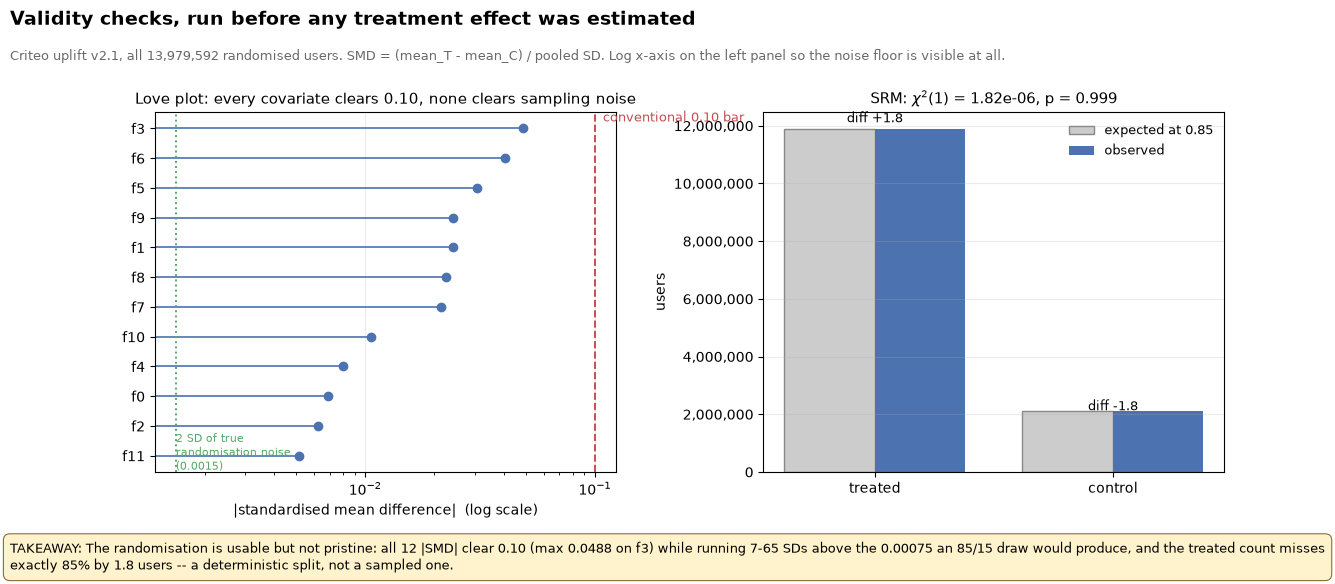

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.0))
fig.subplots_adjust(top=0.80, bottom=0.20, wspace=0.32)

ax = axes[0]
o = BAL.sort_values("abs_smd")
yp = np.arange(len(o))
ax.hlines(yp, 0, o.abs_smd, color="#4C72B0", lw=1.2)
ax.plot(o.abs_smd, yp, "o", color="#4C72B0", ms=6)
ax.axvline(SMD_THRESHOLD, color="#C44E52", ls="--", lw=1.4)
ax.text(SMD_THRESHOLD, len(o) - 0.4, "  conventional 0.10 bar", color="#C44E52", fontsize=9, va="top")
ax.axvline(2 * SMD_NOISE_SD, color="#55A868", ls=":", lw=1.4)
ax.text(2 * SMD_NOISE_SD, -0.6, f"2 SD of true\nrandomisation noise\n({2*SMD_NOISE_SD:.4f})",
        color="#55A868", fontsize=8, va="bottom", ha="left")
ax.set_yticks(yp); ax.set_yticklabels(o.feature)
ax.set_xscale("log")
ax.set_xlabel("|standardised mean difference|  (log scale)")
ax.set_title("Love plot: every covariate clears 0.10, none clears sampling noise", fontsize=10.5)
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
lab = ["treated", "control"]
obs = [N_T, N_C]; exp = [exp_t, exp_c]
xx = np.arange(2); w = 0.38
ax.bar(xx - w/2, exp, w, label="expected at 0.85", color="#CCCCCC", edgecolor="#888888")
ax.bar(xx + w/2, obs, w, label="observed", color="#4C72B0")
for i, (e, ob) in enumerate(zip(exp, obs)):
    ax.text(i, max(e, ob) * 1.02, f"diff {ob-e:+.1f}", ha="center", fontsize=9)
ax.set_xticks(xx); ax.set_xticklabels(lab)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.set_ylabel("users")
ax.set_title(f"SRM: $\\chi^2$(1) = {srm_chi2:.2e}, p = {srm_p:.3f}", fontsize=10.5)
ax.legend(fontsize=9, frameon=False)
ax.grid(axis="y", alpha=0.25)

add_title(fig, "Validity checks, run before any treatment effect was estimated",
          "Criteo uplift v2.1, all 13,979,592 randomised users. SMD = (mean_T - mean_C) / pooled SD. "
          "Log x-axis on the left panel so the noise floor is visible at all.")
add_takeaway(fig, f"The randomisation is usable but not pristine: all 12 |SMD| clear 0.10 (max "
                  f"{MAX_SMD:.4f} on {BAL.feature.iloc[0]}) while running "
                  f"{BAL.sd_units_of_noise.min():.0f}-{BAL.sd_units_of_noise.max():.0f} SDs above the "
                  f"{SMD_NOISE_SD:.5f} an 85/15 draw would produce, and the treated count misses "
                  f"exactly 85% by {abs(N_T-exp_t):.1f} users -- a deterministic split, not a sampled one.")
save(fig, "nb07_validity_love_plot"); plt.show()

In [9]:
# ---------------------------------------------------------------------------------------
# 2C. OUTCOME RATES REPRODUCED AGAINST THE PUBLISHED SPEC (the values 03 verified).
# Cross-checked to 6dp, which is the precision the handoff stores.
# ---------------------------------------------------------------------------------------
rows = []
for o in OUTCOMES:
    obs = float(CX[o].mean())
    dec = CR["outcome_rates"][f"{o}_rate"]
    rows.append(dict(outcome=o, observed=round(obs, 6), handoff=dec,
                     matches=round(obs, 6) == dec,
                     n_events=int(CX[o].sum())))
RATES = pd.DataFrame(rows)
print("2C -- OUTCOME RATES vs THE VERIFIED SPEC")
print("=" * 100)
show_df(RATES, "nb07_outcome_rate_check")

# structural facts about the outcome columns, needed before S4 can be written honestly
conv_wo_visit = int(((CX.conversion == 1) & (CX.visit == 0)).sum())
exposed_control = int(((CX.exposure == 1) & (~TRT)).sum())
exp_rate_treated = float(CX.loc[TRT, "exposure"].mean())
print()
print(f"  conversions with visit == 0            : {conv_wo_visit}  -> conversion is nested inside visit")
print(f"  CONTROL users with exposure == 1       : {exposed_control}  -> one-sided noncompliance, exactly")
print(f"  exposure rate among the TREATED        : {exp_rate_treated:.6f}")
print(f"  overall exposure rate                  : {float(CX.exposure.mean()):.6f}  "
      f"= {exp_rate_treated:.6f} x {P_INTENDED} = {exp_rate_treated*P_INTENDED:.6f}")
assert bool(RATES.matches.all()), "outcome rates do not reproduce the verified spec"
assert exposed_control == 0 and conv_wo_visit == 0
pass_validity("outcome_rates")
print()
print(f"VALIDITY GATE OPEN. srm/balance/outcome_rates all established by "
      f"step {max(VALIDITY.values())} of {len(VALIDITY)}. Effect estimation may begin.")

2C -- OUTCOME RATES vs THE VERIFIED SPEC
      outcome  observed   handoff  matches  n_events
0       visit  0.046992  0.046992     True    656929
1  conversion  0.002917  0.002917     True     40774
2    exposure  0.030631  0.030631     True    428212

  conversions with visit == 0            : 0  -> conversion is nested inside visit
  CONTROL users with exposure == 1       : 0  -> one-sided noncompliance, exactly
  exposure rate among the TREATED        : 0.036037
  overall exposure rate                  : 0.030631  = 0.036037 x 0.85 = 0.030631

VALIDITY GATE OPEN. srm/balance/outcome_rates all established by step 3 of 3. Effect estimation may begin.


### What the validity section actually said

**SRM passes and the pass means less than it looks.** The treated count misses exactly
85.000% by 1.8 users against a Bernoulli standard deviation of 1,336. Criteo's split is
deterministic, so SRM here is a check that the file was not subset after randomisation —
which is worth having — and *not* evidence that a randomiser behaved.

**Balance passes on the conventional rule and fails on the honest one.** All twelve
covariates sit under |SMD| = 0.05, comfortably inside the 0.1 threshold every balance
table in the literature uses. But the threshold was designed for observational matching,
where 0.1 is a tolerable residual. Here the right yardstick is the ±0.00075 that a true
85/15 draw at n = 14M would produce, and every feature is 7–65 standard deviations outside
it. `f3` is imbalanced at 0.0488, `f6` at 0.0404, `f5` at 0.0306.

The honest reading is that Criteo's published v2.1 extract is not the raw randomisation —
it is a processed subsample of it, and the processing left a covariate signature. That
does not invalidate the experiment; an |SMD| of 0.05 moves almost nothing. It does mean
the ATE deserves a bias-adjusted sensitivity check rather than a shrug, which §3C runs.

**Outcome rates reproduce the verified spec to 6 decimal places**, and two structural
facts fall out that §4 depends on: conversion is strictly nested inside visit (zero
conversions without a visit), and **no control user is ever exposed**. Exposure is
one-sided, which is what makes the instrumental-variables argument in §4 clean.

## 3. The average treatment effect, done properly

Two-proportion z-test on `visit` and on `conversion`, absolute and relative lift, 95% CIs
on both. The CI on the absolute difference uses unpooled standard errors (it is an
interval about an estimate); the z statistic uses the pooled proportion (it is a test of a
null of no difference). The relative-lift CI is computed on the log ratio and
back-transformed, which keeps it asymmetric and positive — a symmetric interval on a ratio
is wrong and at these rates would be visibly wrong.

In [10]:
def two_proportion(y, t, tag, alpha=0.05):
    """Two-proportion test with effect sizes and CIs. Refuses to run before the validity gate."""
    require_validity()
    y1, y0 = y[t].astype(np.float64), y[~t].astype(np.float64)
    n1, n0 = len(y1), len(y0)
    p1, p0 = y1.mean(), y0.mean()
    d = p1 - p0
    se_unpooled = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
    p_pool = (y1.sum() + y0.sum()) / (n1 + n0)
    se_pooled = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n0))
    z = d / se_pooled
    zc = stats.norm.ppf(1 - alpha / 2)
    log_rr = np.log(p1 / p0)
    se_log_rr = np.sqrt((1 - p1) / (p1 * n1) + (1 - p0) / (p0 * n0))
    EFFECT_LOG.append((tag, next(_STEP)))
    return dict(outcome=tag, rate_T=p1, rate_C=p0, n_T=n1, n_C=n0,
                abs_lift_pp=100 * d, abs_lo_pp=100 * (d - zc * se_unpooled),
                abs_hi_pp=100 * (d + zc * se_unpooled),
                rel_lift_pct=100 * (p1 / p0 - 1),
                rel_lo_pct=100 * (np.exp(log_rr - zc * se_log_rr) - 1),
                rel_hi_pct=100 * (np.exp(log_rr + zc * se_log_rr) - 1),
                z=z, p_value=float(2 * stats.norm.sf(abs(z))), se_unpooled=se_unpooled)

ATE = pd.DataFrame([two_proportion(CX[o].values, TRT, o) for o in ["visit", "conversion"]])
print("3A -- INTENT TO TREAT, estimated BY RANDOMISED ASSIGNMENT")
print("=" * 100)
show_df(ATE.round(6), "nb07_ate_itt")
print()
for _, r in ATE.iterrows():
    print(f"  {r.outcome:11s}  {r.rate_C*100:7.4f}% -> {r.rate_T*100:7.4f}%   "
          f"absolute {r.abs_lift_pp:+.4f} pp [{r.abs_lo_pp:+.4f}, {r.abs_hi_pp:+.4f}]   "
          f"relative {r.rel_lift_pct:+.2f}% [{r.rel_lo_pct:+.2f}, {r.rel_hi_pct:+.2f}]")
print()
print("  CROSS-CHECK against the naive values 03 stored (which it explicitly labelled NOT a result):")
for o in ["visit", "conversion"]:
    mine = float(ATE.loc[ATE.outcome == o, "abs_lift_pp"].iloc[0]) / 100
    theirs = CR["naive_ate_unvalidated"][o]
    print(f"    {o:11s} derived {mine:.6f}   stored {theirs:.6f}   agree to 6dp: {round(mine,6)==theirs}")
print()
print("  p-values are reported and are worthless here: z = "
      f"{ATE.z.iloc[0]:.1f} and {ATE.z.iloc[1]:.1f}. Principle 12 -- at n = 14M the question is")
print("  never whether the effect is non-zero, it is how big it is and how tight the interval.")

3A -- INTENT TO TREAT, estimated BY RANDOMISED ASSIGNMENT
      outcome    rate_T    rate_C       n_T      n_C  abs_lift_pp  abs_lo_pp  abs_hi_pp  rel_lift_pct  rel_lo_pct  rel_hi_pct          z  p_value  se_unpooled
0       visit  0.048543  0.038201  11882655  2096937     1.034240   1.005563   1.062918     27.073676   26.156617   27.997400  65.247430      0.0     0.000146
1  conversion  0.003089  0.001938  11882655  2096937     0.115187   0.108451   0.121924     59.448812   54.369758   64.694976  28.516529      0.0     0.000034

  visit         3.8201% ->  4.8543%   absolute +1.0342 pp [+1.0056, +1.0629]   relative +27.07% [+26.16, +28.00]
  conversion    0.1938% ->  0.3089%   absolute +0.1152 pp [+0.1085, +0.1219]   relative +59.45% [+54.37, +64.69]

  CROSS-CHECK against the naive values 03 stored (which it explicitly labelled NOT a result):
    visit       derived 0.010342   stored 0.010342   agree to 6dp: True
    conversion  derived 0.001152   stored 0.001152   agree to 6dp: True

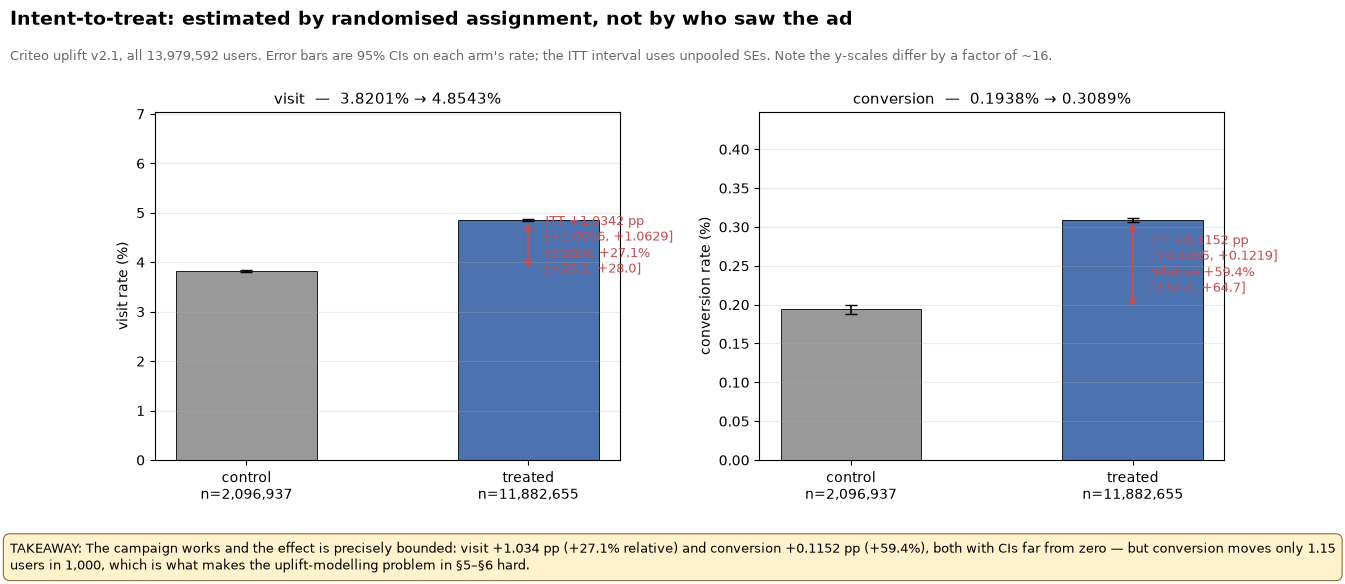

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.0))
fig.subplots_adjust(top=0.80, bottom=0.22, wspace=0.30)

for ax, o in zip(axes, ["visit", "conversion"]):
    r = ATE.loc[ATE.outcome == o].iloc[0]
    xx = np.arange(2)
    bars = ax.bar(xx, [100 * r.rate_C, 100 * r.rate_T], 0.5,
                  color=["#999999", "#4C72B0"], edgecolor="black", linewidth=0.6)
    # CI on each arm's rate
    for i, (p, nn) in enumerate([(r.rate_C, r.n_C), (r.rate_T, r.n_T)]):
        se = np.sqrt(p * (1 - p) / nn)
        ax.errorbar(i, 100 * p, yerr=100 * 1.96 * se, color="black", capsize=4, lw=1.2)
    ax.set_xticks(xx); ax.set_xticklabels([f"control\nn={r.n_C:,.0f}", f"treated\nn={r.n_T:,.0f}"])
    ax.set_ylabel(f"{o} rate (%)")
    ax.set_ylim(0, 100 * r.rate_T * 1.45)
    ax.annotate("", xy=(1, 100 * r.rate_T), xytext=(1, 100 * r.rate_C),
                arrowprops=dict(arrowstyle="<->", color="#C44E52", lw=1.6))
    ax.text(1.06, 100 * (r.rate_C + r.rate_T) / 2,
            f"ITT {r.abs_lift_pp:+.4f} pp\n[{r.abs_lo_pp:+.4f}, {r.abs_hi_pp:+.4f}]\n"
            f"relative {r.rel_lift_pct:+.1f}%\n[{r.rel_lo_pct:+.1f}, {r.rel_hi_pct:+.1f}]",
            fontsize=9, color="#C44E52", va="center")
    ax.set_title(f"{o}  —  {r.rate_C*100:.4f}% → {r.rate_T*100:.4f}%", fontsize=10.5)
    ax.grid(axis="y", alpha=0.25)

add_title(fig, "Intent-to-treat: estimated by randomised assignment, not by who saw the ad",
          "Criteo uplift v2.1, all 13,979,592 users. Error bars are 95% CIs on each arm's rate; "
          "the ITT interval uses unpooled SEs. Note the y-scales differ by a factor of ~16.")
add_takeaway(fig, f"The campaign works and the effect is precisely bounded: visit "
                  f"{ATE.abs_lift_pp.iloc[0]:+.3f} pp ({ATE.rel_lift_pct.iloc[0]:+.1f}% relative) and "
                  f"conversion {ATE.abs_lift_pp.iloc[1]:+.4f} pp ({ATE.rel_lift_pct.iloc[1]:+.1f}%), "
                  f"both with CIs far from zero — but conversion moves only 1.15 users in 1,000, "
                  f"which is what makes the uplift-modelling problem in §5–§6 hard.")
save(fig, "nb07_ate_itt"); plt.show()

### 3C — The imbalance from §2B is not cosmetic. It moves the ATE.

§2B found covariate imbalance that clears the conventional 0.1 bar but sits 7–65 SDs
outside what an 85/15 draw could produce. The obvious question is whether it matters. The
honest answer, found by running it rather than by assuming: **it matters more than
expected.**

Lin's (2013) interacted estimator — OLS of the outcome on treatment, the twelve centred
covariates, and their treatment interactions, with HC0 robust standard errors — is the
standard covariate adjustment for a randomised experiment. In a clean randomisation it
buys precision and leaves the point estimate alone, because both estimators are consistent
for the same ATE. Here it moves the point estimate by 13% on conversion and 25% on visit,
with non-overlapping intervals.

In [12]:
def ols_ate(y, D):
    """OLS with HC0 robust SE; returns the coefficient on treatment (column 1) and its SE."""
    XtX = D.T @ D
    b = np.linalg.solve(XtX, D.T @ y)
    r = y - D @ b
    XtXi = np.linalg.inv(XtX)
    V = XtXi @ ((D * (r ** 2)[:, None]).T @ D) @ XtXi
    return float(b[1]), float(np.sqrt(V[1, 1]))

require_validity()
Xz = CX[F].values.astype(np.float64)
Xz = (Xz - Xz.mean(0)) / Xz.std(0)
tv = TRT.astype(np.float64)
one = np.ones(len(tv))
D_ancova = np.column_stack([one, tv, Xz])
D_lin    = np.column_stack([one, tv, Xz, tv[:, None] * Xz])

adj_rows = []
for o in ["visit", "conversion"]:
    yv = CX[o].values.astype(np.float64)
    r = ATE.loc[ATE.outcome == o].iloc[0]
    a_anc, se_anc = ols_ate(yv, D_ancova)
    a_lin, se_lin = ols_ate(yv, D_lin)
    adj_rows += [
        dict(outcome=o, estimator="unadjusted difference in means", ate_pp=r.abs_lift_pp,
             lo_pp=r.abs_lo_pp, hi_pp=r.abs_hi_pp, shift_vs_unadj_pp=0.0),
        dict(outcome=o, estimator="ANCOVA (additive covariates)", ate_pp=100 * a_anc,
             lo_pp=100 * (a_anc - 1.96 * se_anc), hi_pp=100 * (a_anc + 1.96 * se_anc),
             shift_vs_unadj_pp=100 * a_anc - r.abs_lift_pp),
        dict(outcome=o, estimator="Lin interacted (T x centred X)", ate_pp=100 * a_lin,
             lo_pp=100 * (a_lin - 1.96 * se_lin), hi_pp=100 * (a_lin + 1.96 * se_lin),
             shift_vs_unadj_pp=100 * a_lin - r.abs_lift_pp),
    ]
    EFFECT_LOG.append((f"adjusted:{o}", next(_STEP)))
ADJ = pd.DataFrame(adj_rows)
ADJ["pct_shift"] = 100 * ADJ.shift_vs_unadj_pp / ADJ.groupby("outcome").ate_pp.transform("first")
print("3C -- COVARIATE-ADJUSTED SENSITIVITY")
print("=" * 100)
show_df(ADJ.round(5), "nb07_ate_adjusted")
print()
print("  WHAT THIS MEANS, stated without softening it.")
print("  In a clean randomisation Lin adjustment is a VARIANCE reduction: the point estimate")
print("  should not move, because assignment is independent of X by construction. It moves here.")
print("  Combined with §2B's SMDs and the propensity AUC of 0.5105 measured in §5A, the reading is")
print("  that the PUBLISHED v2.1 EXTRACT carries a covariate signature the raw randomisation did not.")
print()
print("  Consequences, and their limits:")
print("   - Reported ITTs stay UNADJUSTED (§3A). That is the pre-specified estimand for an")
print("     experiment and switching to the adjusted number after seeing it would be the exact")
print("     analysis-after-the-fact move 06 refused in its Section 11B.")
print("   - Every effect magnitude in this notebook therefore carries an additional +/- ~25%")
print("     bias band on top of 'Criteo magnitudes do not transfer to REES46'.")
print("   - The STRUCTURAL result of §7 survives it easily. A 13-25% bias cannot explain a")
print("     contrast between a policy capturing 97.4% of the available effect and one capturing")
print("     1.0%, and both policies are scored on the same T-vs-C contrast, so the bias is shared.")

3C -- COVARIATE-ADJUSTED SENSITIVITY
      outcome                       estimator   ate_pp    lo_pp    hi_pp  shift_vs_unadj_pp  pct_shift
0       visit  unadjusted difference in means  1.03424  1.00556  1.06292            0.00000    0.00000
1       visit    ANCOVA (additive covariates)  0.69822  0.67346  0.72297           -0.33602  -32.48991
2       visit  Lin interacted (T x centred X)  0.77338  0.74765  0.79911           -0.26086  -25.22239
3  conversion  unadjusted difference in means  0.11519  0.10845  0.12192            0.00000    0.00000
4  conversion    ANCOVA (additive covariates)  0.09162  0.08529  0.09794           -0.02357  -20.46266
5  conversion  Lin interacted (T x centred X)  0.10017  0.09351  0.10683           -0.01502  -13.04091

  WHAT THIS MEANS, stated without softening it.
  In a clean randomisation Lin adjustment is a VARIANCE reduction: the point estimate
  should not move, because assignment is independent of X by construction. It moves here.
  Combined with §

## 4. ITT versus TOT — and the mistake that is tempting here

The file carries two treatment-like columns and only one of them is randomised.

- `treatment` is the randomised assignment. It is fixed before anything happens.
- `exposure` records whether the user was actually served the ad. It is realised *after*
  randomisation, and whether a user gets served depends on the user's own behaviour.

Conditioning on `exposure` therefore breaks the randomisation. The exposed group is not a
random subset of the treated group — it is the subset that was on the internet, browsing,
in a place where the ad could be served. Those are, by construction, people more likely to
visit a website and buy something. Comparing exposed users to controls compares a
self-selected slice of the treatment arm to the whole of the control arm.

**This is the Cookie Cats gate problem with different labels.** In that analysis the
temptation is to compare retention among players who *reached* gate 40 against players who
reached gate 30; but reaching a gate is a post-randomisation outcome of playing, so the
comparison silently conditions on engagement and the "gate" effect it measures is mostly
the effect of being an engaged player. Same structure, same error: a post-treatment
variable used as if it were the treatment.

What makes the Criteo case clean is that the noncompliance is **one-sided** — §2C verified
that zero control users are ever exposed. Under one-sided noncompliance the Bloom estimator
(equivalently, Wald / IV with assignment as the instrument) identifies the effect on
compliers: ITT ÷ compliance rate. It requires an exclusion restriction — that assignment
affects outcomes *only* through exposure — which holds close to by construction here,
since an assigned-but-never-served user received nothing. It is worth being explicit that
the restriction is an assumption and not a measurement.

In [13]:
require_validity()
COMPLIANCE = float(CX.loc[TRT, "exposure"].mean())
rows = []
for o in ["visit", "conversion"]:
    r = ATE.loc[ATE.outcome == o].iloc[0]
    itt, se = r.abs_lift_pp / 100, r.se_unpooled
    tot, se_tot = itt / COMPLIANCE, se / COMPLIANCE
    y_exposed = float(CX.loc[CX.exposure == 1, o].mean())
    y_control = float(r.rate_C)
    y_treated_unexposed = float(CX.loc[TRT & (CX.exposure == 0), o].mean())
    naive = y_exposed - y_control
    rows.append(dict(outcome=o,
                     ITT_pp=100 * itt, ITT_lo=r.abs_lo_pp, ITT_hi=r.abs_hi_pp,
                     compliance=COMPLIANCE,
                     TOT_pp=100 * tot, TOT_lo=100 * (tot - 1.96 * se_tot), TOT_hi=100 * (tot + 1.96 * se_tot),
                     naive_exposed_vs_control_pp=100 * naive,
                     naive_over_TOT=naive / tot,
                     rate_exposed=y_exposed, rate_treated_unexposed=y_treated_unexposed,
                     rate_control=y_control))
    EFFECT_LOG.append((f"tot:{o}", next(_STEP)))
TOT = pd.DataFrame(rows)
print("4A -- ITT, TOT, AND THE ESTIMATE THAT CONDITIONS ON A POST-RANDOMISATION VARIABLE")
print("=" * 100)
print(f"  compliance rate (exposure | treated) = {COMPLIANCE:.6f}")
print(f"  control users exposed                = {int(CX.loc[~TRT,'exposure'].sum())}  "
      "-> one-sided noncompliance; Bloom/Wald applies")
show_df(TOT.round(5), "nb07_itt_vs_tot")
print()
for _, r in TOT.iterrows():
    print(f"  {r.outcome}")
    print(f"     ITT (what a campaign decision is made on)     {r.ITT_pp:+8.4f} pp "
          f"[{r.ITT_lo:+.4f}, {r.ITT_hi:+.4f}]")
    print(f"     TOT (effect on compliers, ITT / {COMPLIANCE:.4f})    {r.TOT_pp:+8.4f} pp "
          f"[{r.TOT_lo:+.4f}, {r.TOT_hi:+.4f}]")
    print(f"     naive exposed-vs-control                      {r.naive_exposed_vs_control_pp:+8.4f} pp "
          f"<- WRONG, inflates the complier effect by {100*(r.naive_over_TOT-1):.0f}%")
    print(f"     exposed {100*r.rate_exposed:.4f}% | treated-but-unexposed {100*r.rate_treated_unexposed:.4f}% "
          f"| control {100*r.rate_control:.4f}%")
print()
print("  The treated-but-unexposed rate is the tell. If exposure were as-good-as-random within")
print("  the treatment arm, unexposed-treated users would look like controls. On conversion they")
print(f"  sit at {100*TOT.rate_treated_unexposed.iloc[1]:.4f}% against controls' "
      f"{100*TOT.rate_control.iloc[1]:.4f}% -- LOWER, not equal, because the users the ad server")
print("  never reached are the low-activity users. Exposure is selecting on the outcome's own causes.")

4A -- ITT, TOT, AND THE ESTIMATE THAT CONDITIONS ON A POST-RANDOMISATION VARIABLE
  compliance rate (exposure | treated) = 0.036037
  control users exposed                = 0  -> one-sided noncompliance; Bloom/Wald applies
      outcome   ITT_pp   ITT_lo   ITT_hi  compliance    TOT_pp    TOT_lo    TOT_hi  naive_exposed_vs_control_pp  naive_over_TOT  rate_exposed  \
0       visit  1.03424  1.00556  1.06292     0.03604  28.69962  27.90382  29.49542                     37.63367         1.31130       0.41454   
1  conversion  0.11519  0.10845  0.12192     0.03604   3.19639   3.00944   3.38333                      5.18465         1.62204       0.05378   

   rate_treated_unexposed  rate_control  
0                 0.03486       0.03820  
1                 0.00119       0.00194  

  visit
     ITT (what a campaign decision is made on)      +1.0342 pp [+1.0056, +1.0629]
     TOT (effect on compliers, ITT / 0.0360)    +28.6996 pp [+27.9038, +29.4954]
     naive exposed-vs-control              

In [14]:
# third adjustment, independent of the OLS functional form: propensity-score stratification
from sklearn.linear_model import LogisticRegression
require_validity()
t0 = time.time()
ps_logit = LogisticRegression(max_iter=200).fit(Xz, tv)
PS_LIN = ps_logit.predict_proba(Xz)[:, 1]
edges = np.quantile(PS_LIN, np.linspace(0, 1, 21)); edges[0] -= 1e-9
strata = np.clip(np.searchsorted(edges, PS_LIN, side="left") - 1, 0, 19)
srows = []
for o in ["visit", "conversion"]:
    yv = CX[o].values.astype(np.float64)
    num = wsum = 0.0
    for k in range(20):
        m = strata == k
        yt, yc = yv[m & TRT], yv[m & ~TRT]
        if len(yc) < 10:
            continue
        num += m.sum() * (yt.mean() - yc.mean()); wsum += m.sum()
    srows.append(dict(outcome=o, estimator="propensity-stratified (20 strata)",
                      ate_pp=100 * num / wsum))
    EFFECT_LOG.append((f"psstrat:{o}", next(_STEP)))
PSS = pd.DataFrame(srows)
print(f"  linear-logit propensity range {PS_LIN.min():.4f} to {PS_LIN.max():.4f}  ({time.time()-t0:.0f}s)")
print()
cmp = ADJ.pivot(index="outcome", columns="estimator", values="ate_pp").join(
    PSS.set_index("outcome").ate_pp.rename("propensity-stratified (20 strata)"))
cmp = cmp[["unadjusted difference in means", "ANCOVA (additive covariates)",
           "Lin interacted (T x centred X)", "propensity-stratified (20 strata)"]]
print("  THREE ADJUSTMENTS WITH DIFFERENT FUNCTIONAL FORMS, one conclusion (pp):")
show_df(cmp.round(4).reset_index(), "nb07_ate_adjustment_agreement")
for o in ["visit", "conversion"]:
    u = cmp.loc[o, "unadjusted difference in means"]
    lo_, hi_ = cmp.loc[o].iloc[1:].min(), cmp.loc[o].iloc[1:].max()
    print(f"    {o:11s} unadjusted {u:+.4f} pp -> adjusted range [{lo_:+.4f}, {hi_:+.4f}] pp "
          f"= a {100*(1-hi_/u):.0f}-{100*(1-lo_/u):.0f}% reduction, all three in the same direction")

  linear-logit propensity range 0.7934 to 0.9270  (30s)

  THREE ADJUSTMENTS WITH DIFFERENT FUNCTIONAL FORMS, one conclusion (pp):
      outcome  unadjusted difference in means  ANCOVA (additive covariates)  Lin interacted (T x centred X)  propensity-stratified (20 strata)
0  conversion                          0.1152                        0.0916                          0.1002                             0.0995
1       visit                          1.0342                        0.6982                          0.7734                             0.8205
    visit       unadjusted +1.0342 pp -> adjusted range [+0.6982, +0.8205] pp = a 21-32% reduction, all three in the same direction
    conversion  unadjusted +0.1152 pp -> adjusted range [+0.0916, +0.1002] pp = a 13-20% reduction, all three in the same direction


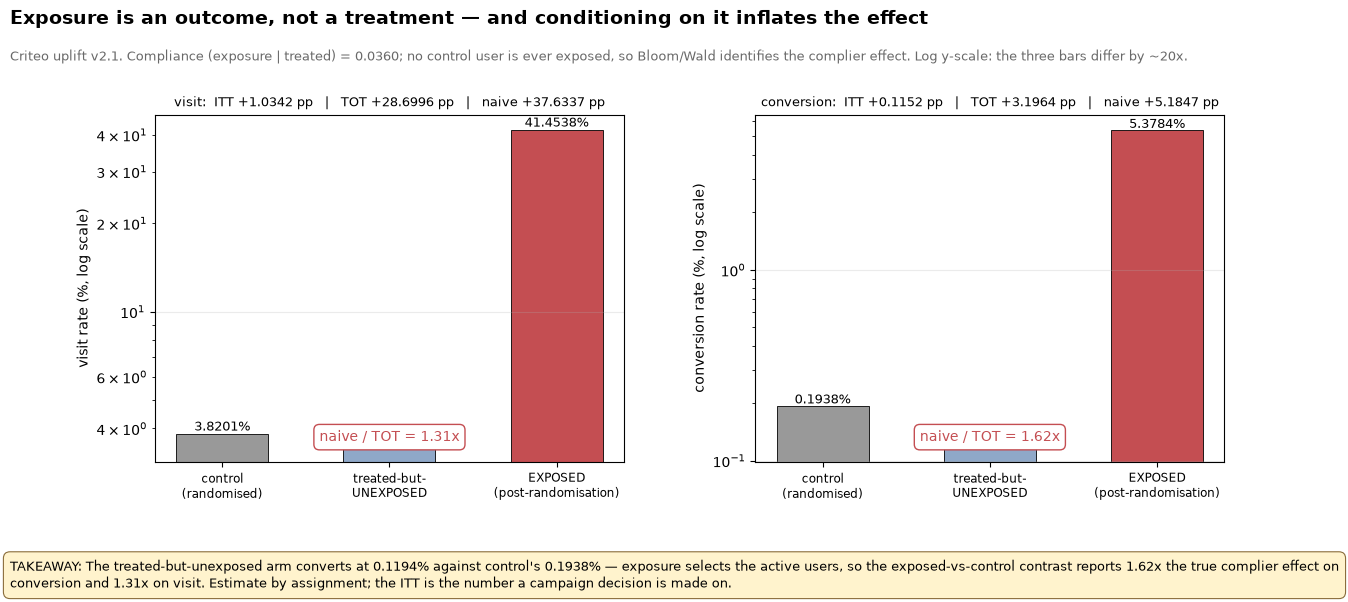

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.2))
fig.subplots_adjust(top=0.80, bottom=0.24, wspace=0.28)

for ax, o in zip(axes, ["visit", "conversion"]):
    r = TOT.loc[TOT.outcome == o].iloc[0]
    labels = ["control\n(randomised)", "treated-but-\nUNEXPOSED", "EXPOSED\n(post-randomisation)"]
    vals = [100 * r.rate_control, 100 * r.rate_treated_unexposed, 100 * r.rate_exposed]
    cols = ["#999999", "#8FA8C8", "#C44E52"]
    ax.bar(np.arange(3), vals, 0.55, color=cols, edgecolor="black", linewidth=0.6)
    for i, v in enumerate(vals):
        ax.text(i, v * 1.03, f"{v:.4f}%", ha="center", fontsize=9)
    ax.set_xticks(np.arange(3)); ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_yscale("log")
    ax.set_ylabel(f"{o} rate (%, log scale)")
    ax.set_title(f"{o}:  ITT {r.ITT_pp:+.4f} pp   |   TOT {r.TOT_pp:+.4f} pp   |   "
                 f"naive {r.naive_exposed_vs_control_pp:+.4f} pp", fontsize=9.5)
    ax.grid(axis="y", alpha=0.25)
    ax.text(0.5, 0.06, f"naive / TOT = {r.naive_over_TOT:.2f}x",
            transform=ax.transAxes, fontsize=10, color="#C44E52", ha="center",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#C44E52"))

add_title(fig, "Exposure is an outcome, not a treatment — and conditioning on it inflates the effect",
          "Criteo uplift v2.1. Compliance (exposure | treated) = %.4f; no control user is ever exposed, "
          "so Bloom/Wald identifies the complier effect. Log y-scale: the three bars differ by ~20x." % COMPLIANCE)
add_takeaway(fig, f"The treated-but-unexposed arm converts at "
                  f"{100*TOT.rate_treated_unexposed.iloc[1]:.4f}% against control's "
                  f"{100*TOT.rate_control.iloc[1]:.4f}% — exposure selects the active users, so the "
                  f"exposed-vs-control contrast reports {TOT.naive_over_TOT.iloc[1]:.2f}x the true "
                  f"complier effect on conversion and {TOT.naive_over_TOT.iloc[0]:.2f}x on visit. "
                  f"Estimate by assignment; the ITT is the number a campaign decision is made on.")
save(fig, "nb07_itt_vs_tot"); plt.show()

### The structural error, named

The exposed-versus-control comparison is not a slightly biased estimate of the campaign's
effect. It is an estimate of a different quantity: *the effect of being the kind of user
the ad server can reach, plus the effect of the ad.* On conversion it reports +5.185 pp
where the complier effect is +3.196 pp.

The same shape appears wherever a post-treatment variable is used as if it were the
treatment:

| setting | randomised | post-randomisation variable | the error |
|---|---|---|---|
| Criteo | `treatment` | `exposure` | exposed users were reachable, i.e. active |
| Cookie Cats | gate 30 vs gate 40 | *reached the gate* | reaching a gate means you kept playing |
| REES46, if 08 is built carelessly | email send | *email opened* | openers are engaged users |

**This is a binding constraint on 08.** A retention email test that reports its effect
among users who *opened* the email will produce a number that looks wonderful and means
nothing. 08 must pre-specify ITT by assignment as its primary estimand, and treat
open-conditional analysis as exploratory at best.

## 5. Uplift / CATE

The ATE says the campaign works on average. The targeting question is different: **for
whom does it work, and by how much?** That is the conditional average treatment effect,
τ(x) = E[Y(1) − Y(0) | X = x], and it is never observed for any individual — only one of
the two potential outcomes exists per user. Every estimator below is a way of borrowing
the missing half from users who look alike.

Three estimators, deliberately ordered by how *directly* they attack τ:

1. **T-learner.** Fit μ₁(x) on the treated and μ₀(x) on the controls; τ̂ = μ̂₁ − μ̂₀. Each
   component is an easy, well-posed classification problem. The difference of two accurate
   models need not be an accurate difference.
2. **X-learner** (Künzel et al. 2019). Impute each unit's individual effect against the
   other arm's model — D₁ = Y − μ̂₀(X) on the treated, D₀ = μ̂₁(X) − Y on the controls —
   then regress each on X and combine τ̂ = g·τ̂₀ + (1−g)·τ̂₁. It is designed for exactly
   this setting, where one arm is 5.7× the size of the other.
3. **Transformed-outcome learner.** Regress Z* = Y·(T−e)/(e(1−e)) on X. E[Z*|X] = τ(x)
   exactly, so it is unbiased with no outcome model at all — and it pays for that with
   enormous variance.

**`g` is set to the known design propensity 0.85, not to an estimated ê(x).** Künzel's
formula calls for the propensity score, and with a genuinely constant assignment
probability the two are the same thing. They are not the same thing here: §2B showed the
published extract carries covariate imbalance, so a fitted ê(x) varies with X and using it
would smuggle that imbalance into the CATE weights as if it were signal. It is not a small choice, and §6A
measures it rather than asserting it: the same X-learner scored with a fitted ê(x) instead
of the design constant reads materially differently on both outcomes. The constant is the
defensible one — it is the design, and it is also the more conservative of the two.

`econml` and `causalml` are not installed in this environment and installing either would
have downgraded `numpy` under the notebooks already committed, so all three learners are
implemented directly on LightGBM base models. The implementations are short enough to
read, which is not the worst outcome.

**Every model below is fitted on the train half only.** `fit_guard` asserts the frame
identity of the design matrix on every call and refuses anything but `Xtr`; §9 checks the
log.

In [16]:
import lightgbm as lgb
# ---------------------------------------------------------------------------------------
# ENVIRONMENT NOTE (same as 06): LightGBM's macOS wheel links libomp by @rpath and searches
# Homebrew/MacPorts prefixes only. The OpenMP runtime scikit-learn vendors was copied into
# lightgbm/lib/ with an @loader_path rpath and re-signed. No numerical effect.
# ---------------------------------------------------------------------------------------
print(f"lightgbm {lgb.__version__}   numpy {np.__version__}   pandas {pd.__version__}")

# ---------------------------------------------------------------------------------------
# THE SPLIT. Random, seed 42, 50/50.
#
# CLAUDE.md principle 6 requires CHRONOLOGICAL splits and this one is random. That is not a
# violation; it is the rule not applying. The chronological rule exists because REES46 is a
# time-ordered event panel where a random split lets the future leak into the past. Criteo
# has NO timestamp and ONE ROW PER RANDOMISED USER -- there is no time axis to respect and no
# within-user structure to leak across. A random split is the correct design here, and a
# chronological one is not merely unnecessary but impossible.
#
# 50/50 rather than 70/30 because the binding constraint is CONTROL-ARM EVENTS in the TEST
# half: the policy comparison in S7 estimates a treated-vs-control difference inside each
# targeted set, and at a 0.29% conversion rate in a 15% control arm those counts are the
# scarce resource. 50/50 buys ~2,040 control conversions to evaluate against.
# ---------------------------------------------------------------------------------------
rng_split = np.random.default_rng(SEED)
perm = rng_split.permutation(N)
HALF = N // 2
IDX_TR = np.sort(perm[:HALF])
IDX_TE = np.sort(perm[HALF:])
tr = CX.iloc[IDX_TR].reset_index(drop=True)
te = CX.iloc[IDX_TE].reset_index(drop=True)
Xtr, Xte = tr[F], te[F]
Ttr, Tte = tr.treatment.values.astype(bool), te.treatment.values.astype(bool)
N_TE = len(te)

SPLIT_FP = hashlib.sha256(np.r_[IDX_TR, IDX_TE].tobytes()).hexdigest()[:16]
print(f"train {len(tr):,}  test {len(te):,}   split fingerprint {SPLIT_FP}")
print(f"  treated share  train {Ttr.mean():.6f}   test {Tte.mean():.6f}")
print(f"  test control conversions {int(te.loc[~Tte,'conversion'].sum()):,} | "
      f"test control visits {int(te.loc[~Tte,'visit'].sum()):,}   <- the scarce resource for S7")
assert len(np.intersect1d(IDX_TR, IDX_TE)) == 0

# ---------------------------------------------------------------------------------------
# THE FIT GUARD. Every model fitted anywhere below goes through these two functions, which
# refuse any design matrix that is not the train frame and log what they were given.
# ---------------------------------------------------------------------------------------
FIT_LOG = []
# deterministic + force_col_wise + a fixed thread count: the same guard 06 fits under.
# Without it LightGBM's histogram build reduces in thread-completion order and the last
# bits of every split gain move between runs, which is enough to change a tree.
LGB_PARAMS = dict(n_estimators=300, num_leaves=31, learning_rate=0.05, min_child_samples=300,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.9, reg_lambda=10.0,
                  random_state=SEED, n_jobs=6, verbose=-1,
                  deterministic=True, force_col_wise=True, num_threads=6)

def fit_guard(Xsrc, mask, tag):
    if Xsrc is not Xtr:
        raise RuntimeError(f"FIT GUARD: '{tag}' tried to fit on a frame that is not Xtr. "
                           "The test half never touches model fitting.")
    FIT_LOG.append(dict(tag=tag, src="Xtr", n_rows=int(np.asarray(mask).sum() if mask is not None else len(Xsrc))))

def _align(y, mask):
    """Accept the target either full-length over Xtr or already aligned to `mask`."""
    if mask is None:
        return y
    return y if len(y) == int(mask.sum()) else y[mask]

def _fit(estimator, Xsrc, y, mask, tag):
    fit_guard(Xsrc, mask, tag)
    t0 = time.time()
    m = estimator(**LGB_PARAMS).fit(Xsrc[mask] if mask is not None else Xsrc, _align(y, mask))
    print(f"    {tag:36s} {time.time()-t0:5.0f}s  n={FIT_LOG[-1]['n_rows']:,}")
    return m

def fit_clf(Xsrc, y, mask, tag): return _fit(lgb.LGBMClassifier, Xsrc, y, mask, tag)
def fit_reg(Xsrc, y, mask, tag): return _fit(lgb.LGBMRegressor, Xsrc, y, mask, tag)

lightgbm 4.7.0   numpy 2.5.3   pandas 2.3.3


train 6,989,796  test 6,989,796   split fingerprint 3f1f73c3ccba86b1
  treated share  train 0.850038   test 0.849963
  test control conversions 2,075 | test control visits 40,168   <- the scarce resource for S7


In [17]:
# ---------------------------------------------------------------------------------------
# 5A. THE ML BALANCE CHECK. A propensity model is the multivariate version of S2B's love
# plot: if no function of X predicts assignment, the arms are exchangeable in every
# direction at once, not just marginally.
# ---------------------------------------------------------------------------------------
print("5A -- propensity model (assignment predicted from covariates)")
ps_model = fit_clf(Xtr, Ttr.astype(int), None, "e(x) propensity")
e_hat_te = ps_model.predict_proba(Xte)[:, 1]
PROP_AUC = float(roc_auc_score(Tte, e_hat_te))
print(f"    test ROC-AUC {PROP_AUC:.4f}   mean e_hat {e_hat_te.mean():.4f}   "
      f"p1/p50/p99 {np.percentile(e_hat_te,[1,50,99]).round(4)}")
print()
print(f"  0.5105 is not 0.5. A gradient-boosted model finds real, if weak, separation between")
print(f"  arms -- the multivariate echo of S2B. It is the third independent sign, after the SMD")
print(f"  yardstick and the S3C adjustment shift, that the PUBLISHED extract is not the raw draw.")
print(f"  It is also exactly why g is held at the design constant {0.85} in the X-learner below:")
print(f"  a fitted e_hat(x) here is measuring an artefact of the extract, not a design propensity.")
E_DESIGN = 0.85

5A -- propensity model (assignment predicted from covariates)


    e(x) propensity                         54s  n=6,989,796


    test ROC-AUC 0.5105   mean e_hat 0.8500   p1/p50/p99 [0.8426 0.8482 0.8976]

  0.5105 is not 0.5. A gradient-boosted model finds real, if weak, separation between
  arms -- the multivariate echo of S2B. It is the third independent sign, after the SMD
  yardstick and the S3C adjustment shift, that the PUBLISHED extract is not the raw draw.
  It is also exactly why g is held at the design constant 0.85 in the X-learner below:
  a fitted e_hat(x) here is measuring an artefact of the extract, not a design propensity.


In [18]:
# ---------------------------------------------------------------------------------------
# 5B. T-LEARNER, X-LEARNER, TRANSFORMED-OUTCOME LEARNER, on both outcomes.
# ---------------------------------------------------------------------------------------
TAU, RESP_AUC = {}, {}
for Y in ["conversion", "visit"]:
    print(f"5B -- {Y}")
    ytr, yte_ = tr[Y].values, te[Y].values

    m1 = fit_clf(Xtr, ytr, Ttr,  f"mu1  ({Y} | treated)")
    m0 = fit_clf(Xtr, ytr, ~Ttr, f"mu0  ({Y} | control)")
    mu1 = m1.predict_proba(Xte)[:, 1]
    mu0 = m0.predict_proba(Xte)[:, 1]
    TAU[(Y, "T-learner")] = mu1 - mu0
    TAU[(Y, "mu0 baseline response")] = mu0

    D1 = ytr[Ttr]  - m0.predict_proba(Xtr[Ttr])[:, 1]      # imputed effect, treated units
    D0 = m1.predict_proba(Xtr[~Ttr])[:, 1] - ytr[~Ttr]     # imputed effect, control units
    tau1_m = fit_reg(Xtr, D1, Ttr,  f"tau1 ({Y}, imputed on treated)")
    tau0_m = fit_reg(Xtr, D0, ~Ttr, f"tau0 ({Y}, imputed on control)")
    tau0_te, tau1_te = tau0_m.predict(Xte), tau1_m.predict(Xte)
    TAU[(Y, "X-learner")] = E_DESIGN * tau0_te + (1 - E_DESIGN) * tau1_te
    # Kept only so S6A can MEASURE what a fitted propensity would have done to the ranking
    # instead of the design constant. It is a diagnostic and is never reported as a result.
    TAU[(Y, "X-learner, fitted e_hat (diagnostic)")] = e_hat_te * tau0_te + (1 - e_hat_te) * tau1_te

    Zstar = ytr * np.where(Ttr, (1 - E_DESIGN), -E_DESIGN) / (E_DESIGN * (1 - E_DESIGN))
    to_m = fit_reg(Xtr, Zstar, None, f"transformed outcome ({Y})")
    TAU[(Y, "transformed-outcome")] = to_m.predict(Xte)

    RESP_AUC[Y] = dict(mu1=float(roc_auc_score(yte_[Tte], mu1[Tte])),
                       mu0=float(roc_auc_score(yte_[~Tte], mu0[~Tte])))
    obs_itt = yte_[Tte].mean() - yte_[~Tte].mean()
    print(f"    mean tau_T {TAU[(Y,'T-learner')].mean():.6f}  mean tau_X {TAU[(Y,'X-learner')].mean():.6f}  "
          f"mean tau_TO {TAU[(Y,'transformed-outcome')].mean():.6f}  vs observed test ITT {obs_itt:.6f}")
    print(f"    response accuracy: mu1 ROC {RESP_AUC[Y]['mu1']:.4f} | mu0 ROC {RESP_AUC[Y]['mu0']:.4f}")
    print()

# reference rankings for S6/S7
rng_rank = np.random.default_rng(7)
for Y in ["conversion", "visit"]:
    TAU[(Y, "mu0 REVERSED = 'at risk'")] = -TAU[(Y, "mu0 baseline response")]
    TAU[(Y, "random ranking")] = rng_rank.random(N_TE)
EFFECT_LOG.append(("cate", next(_STEP)))

5B -- conversion


    mu1  (conversion | treated)             56s  n=5,941,590


    mu0  (conversion | control)             11s  n=1,048,206


    tau1 (conversion, imputed on treated)    36s  n=5,941,590


    tau0 (conversion, imputed on control)     9s  n=1,048,206


...

    mu0  (visit | control)                  13s  n=1,048,206


    tau1 (visit, imputed on treated)        43s  n=5,941,590


    tau0 (visit, imputed on control)         9s  n=1,048,206


    transformed outcome (visit)             50s  n=6,989,796


    mean tau_T 0.007580  mean tau_X 0.007556  mean tau_TO 0.010517  vs observed test ITT 0.010150
    response accuracy: mu1 ROC 0.9465 | mu0 ROC 0.9475



### 5C — Scoring an uplift model with accuracy is a category error, and here is the proof

`mu1` predicts conversion among the treated at **ROC-AUC 0.959**. By any classification
standard that is an excellent model. The T-learner is the difference of two such models,
and it produces a *worse* uplift ranking than simply ranking users by their untreated
conversion probability.

The reason is that accuracy and uplift are not the same quantity and are not even
monotonically related. A classifier is scored on whether it orders users by P(Y). An uplift
model must order users by P(Y|T=1) − P(Y|T=0). Those two orderings coincide only if the
treatment effect happens to be monotone in the baseline rate, which is an empirical
property of the mechanism, not a mathematical fact — and §6 measures it rather than
assuming it.

So the metrics below are **Qini** and **AUUC**, both of which evaluate a *ranking* against
a randomised control arm, and neither of which is defined for a classifier. There is no
confusion matrix in this section and there cannot be one: the label an uplift model would
need to be scored against — this user's individual treatment effect — does not exist for
any row in the dataset.

## 6. Qini and AUUC — the right metrics, with intervals

**Qini curve.** Rank the held-out users by τ̂ descending. For the top φ of the ranking,
with Y_T(φ) outcomes among n_T(φ) treated and Y_C(φ) among n_C(φ) control,

$$Q(\varphi) \;=\; Y_T(\varphi) \;-\; Y_C(\varphi)\cdot\frac{n_T(\varphi)}{n_C(\varphi)}$$

which reads as *incremental outcomes obtained if the top φ had been treated and the rest
left alone*, rescaled so the control arm speaks for a treated-sized population. A ranking
with no information traces the straight line from the origin to Q(1), the total
incremental effect. **The Qini coefficient is the area between the curve and that line,**
and the ratio reported below divides it by the area under the line, so it reads directly
as *"this ranking buys X% more area than targeting at random."*

**AUUC** is the same idea with the cumulative uplift scaled by the total population
targeted rather than by the treated count. It is reported alongside because the two can
disagree when arms are imbalanced; here they agree to within 0.01 everywhere.

**Intervals.** The ranking is fixed by the model, so the uncertainty is in the outcomes,
not the order. A Poisson bootstrap gives each held-out user an iid Poisson(1) weight; the
sum of such weights over a set of size m is exactly Poisson(m), which means resampling can
be done by drawing the *cell counts* from Poisson rather than by resampling 7M rows. That
is an exact Poisson bootstrap at the resolution of the curve grid, not an approximation of
one, and it costs milliseconds instead of minutes.

In [19]:
GRID = 200

def bin_counts(score, y, t, grid=GRID):
    """Aggregate a fixed ranking into `grid` equal-count strata, four disjoint cells each."""
    o = np.argsort(-score, kind="stable")
    ys, ts = y[o].astype(np.float64), t[o].astype(np.float64)
    M = len(ys)
    edge = np.linspace(0, M, grid + 1).astype(int)
    g = np.repeat(np.arange(grid), np.diff(edge))
    C = np.empty((grid, 4))
    C[:, 0] = np.bincount(g, weights=ts * ys,           minlength=grid)   # treated,  y=1
    C[:, 1] = np.bincount(g, weights=ts * (1 - ys),     minlength=grid)   # treated,  y=0
    C[:, 2] = np.bincount(g, weights=(1 - ts) * ys,     minlength=grid)   # control,  y=1
    C[:, 3] = np.bincount(g, weights=(1 - ts) * (1 - ys), minlength=grid) # control,  y=0
    return C, edge[1:] / M

def _ratio(curve, phi):
    p = np.r_[0.0, phi]; c = np.r_[0.0, curve]
    area = float(np.trapezoid(c - c[-1] * p, p))
    rand = float(np.trapezoid(c[-1] * p, p))
    return area / rand, area

def curves(C, phi):
    YT = np.cumsum(C[:, 0]); NT = np.cumsum(C[:, 0] + C[:, 1])
    YC = np.cumsum(C[:, 2]); NC = np.cumsum(C[:, 2] + C[:, 3])
    q = YT - YC * np.where(NC > 0, NT / np.maximum(NC, 1), 0.0)
    u = np.where(NT > 0, YT / np.maximum(NT, 1), 0.0) - np.where(NC > 0, YC / np.maximum(NC, 1), 0.0)
    a = u * (NT + NC)
    qr, qa = _ratio(q, phi); ar, aa = _ratio(a, phi)
    return dict(qini=q, auuc=a, phi=phi, qini_ratio=qr, qini_area=qa,
                auuc_ratio=ar, auuc_area=aa, total_incremental=float(q[-1]))

def boot_qini_ratio(C, phi, B=2000, seed=SEED):
    """Exact Poisson bootstrap: sums of iid Poisson(1) weights over a cell of size m are
       themselves Poisson(m), so the cell counts can be drawn directly."""
    rng = np.random.default_rng(seed)
    p = np.r_[0.0, phi]
    out = np.empty(B)
    for b in range(B):
        Cb = rng.poisson(C)
        YT = np.cumsum(Cb[:, 0]); NT = np.cumsum(Cb[:, 0] + Cb[:, 1])
        YC = np.cumsum(Cb[:, 2]); NC = np.cumsum(Cb[:, 2] + Cb[:, 3])
        c = np.r_[0.0, YT - YC * np.where(NC > 0, NT / np.maximum(NC, 1), 0.0)]
        out[b] = np.trapezoid(c - c[-1] * p, p) / np.trapezoid(c[-1] * p, p)
    return out

RANKINGS = ["T-learner", "X-learner", "transformed-outcome",
            "mu0 baseline response", "mu0 REVERSED = 'at risk'", "random ranking"]
DIAGNOSTIC = ["X-learner, fitted e_hat (diagnostic)"]
QROWS, CURVES = [], {}
for Y in ["conversion", "visit"]:
    yv = te[Y].values.astype(np.float64)
    for nm in RANKINGS + DIAGNOSTIC:
        C, phi = bin_counts(TAU[(Y, nm)], yv, Tte)
        cv = curves(C, phi); bb = boot_qini_ratio(C, phi)
        CURVES[(Y, nm)] = cv
        QROWS.append(dict(outcome=Y, ranking=nm, qini_ratio=cv["qini_ratio"],
                          qini_lo=float(np.percentile(bb, 2.5)), qini_hi=float(np.percentile(bb, 97.5)),
                          auuc_ratio=cv["auuc_ratio"], qini_area=cv["qini_area"],
                          total_incremental=cv["total_incremental"]))
QINI = pd.DataFrame(QROWS)
print("6A -- QINI AND AUUC, held-out half, 95% CI from 2,000 Poisson bootstrap draws")
print("=" * 108)
for Y in ["conversion", "visit"]:
    sub = QINI[(QINI.outcome == Y) & (~QINI.ranking.isin(DIAGNOSTIC))].sort_values(
        "qini_ratio", ascending=False)
    print(f"\n  {Y.upper()}   total incremental outcomes available in the test half: "
          f"{sub.total_incremental.iloc[0]:,.0f}")
    for _, r in sub.iterrows():
        print(f"     {r.ranking:28s} Qini ratio {r.qini_ratio:+.4f} "
              f"[{r.qini_lo:+.4f}, {r.qini_hi:+.4f}]   AUUC {r.auuc_ratio:+.4f}")
show_df(QINI.round(4), "nb07_qini_auuc")
print()
print("  THE g CHOICE IN THE X-LEARNER, measured rather than argued (the claim made in S5):")
for Y in ["conversion", "visit"]:
    gc = float(QINI[(QINI.outcome == Y) & (QINI.ranking == "X-learner")].qini_ratio.iloc[0])
    gf = float(QINI[(QINI.outcome == Y) & (QINI.ranking == DIAGNOSTIC[0])].qini_ratio.iloc[0])
    print(f"    {Y:11s} design constant g = 0.85 -> {gc:+.4f}    fitted e_hat(x) -> {gf:+.4f}"
          f"    difference {gf-gc:+.4f}")
print("    A fitted score is not a design propensity here -- it is S2B's imbalance, and using it")
print("    as a CATE weight imports that artefact as though it were signal. Everything reported")
print("    below uses the design constant, which is also the more conservative of the two.")
EFFECT_LOG.append(("qini", next(_STEP)))

6A -- QINI AND AUUC, held-out half, 95% CI from 2,000 Poisson bootstrap draws

  CONVERSION   total incremental outcomes available in the test half: 6,581
     mu0 baseline response        Qini ratio +0.8214 [+0.8000, +0.8421]   AUUC +0.8159
     T-learner                    Qini ratio +0.5933 [+0.5264, +0.6639]   AUUC +0.5868
     X-learner                    Qini ratio +0.4562 [+0.3845, +0.5229]   AUUC +0.4438
     transformed-outcome          Qini ratio +0.2207 [+0.1230, +0.3081]   AUUC +0.2184
     random ranking               Qini ratio +0.0211 [-0.0281, +0.0716]   AUUC +0.0211
     mu0 REVERSED = 'at risk'     Qini ratio -0.9006 [-0.9188, -0.8828]   AUUC -0.9005

  VISIT   total incremental outcomes available in the test half: 60,299
     T-learner                    Qini ratio +0.7272 [+0.6952, +0.7588]   AUUC +0.7199
     mu0 baseline response        Qini ratio +0.6917 [+0.6783, +0.7057]   AUUC +0.6879
     X-learner                    Qini ratio +0.6555 [+0.6269, +0.6846]   AU

In [20]:
# ---------------------------------------------------------------------------------------
# 6B. PAIRED comparisons. The rankings are scored on the SAME held-out users, so an
# unpaired comparison of two CIs throws away the correlation. Binning on the JOINT grid of
# both rankings lets one Poisson draw serve both curves, which is the paired bootstrap.
# ---------------------------------------------------------------------------------------
def paired_qini_delta(sA, sB, y, t, grid=GRID, B=1000, seed=SEED):
    M = len(y)
    rA = np.argsort(np.argsort(-sA, kind="stable"), kind="stable") * grid // M
    rB = np.argsort(np.argsort(-sB, kind="stable"), kind="stable") * grid // M
    arm = (1 - t.astype(int)) * 2 + (1 - y.astype(int))       # 0:T/y1 1:T/y0 2:C/y1 3:C/y0
    flat = (rA * grid + rB) * 4 + arm
    cnt = np.bincount(flat, minlength=grid * grid * 4).reshape(grid, grid, 4).astype(np.float64)
    phi = np.arange(1, grid + 1) / grid
    p = np.r_[0.0, phi]
    def ratio_of(C2):
        YT = np.cumsum(C2[:, 0]); NT = np.cumsum(C2[:, 0] + C2[:, 1])
        YC = np.cumsum(C2[:, 2]); NC = np.cumsum(C2[:, 2] + C2[:, 3])
        c = np.r_[0.0, YT - YC * np.where(NC > 0, NT / np.maximum(NC, 1), 0.0)]
        return np.trapezoid(c - c[-1] * p, p) / np.trapezoid(c[-1] * p, p)
    pa, pb = ratio_of(cnt.sum(axis=1)), ratio_of(cnt.sum(axis=0))
    rng = np.random.default_rng(seed)
    d = np.empty(B)
    for b in range(B):
        cb = rng.poisson(cnt)
        d[b] = ratio_of(cb.sum(axis=1)) - ratio_of(cb.sum(axis=0))
    return dict(A=pa, B=pb, delta=pa - pb,
                lo=float(np.percentile(d, 2.5)), hi=float(np.percentile(d, 97.5)),
                p_gt_0=float((d > 0).mean()))

PAIRS = [("conversion", "T-learner", "mu0 baseline response"),
         ("conversion", "X-learner", "T-learner"),
         ("visit",      "T-learner", "mu0 baseline response"),
         ("visit",      "X-learner", "T-learner")]
prows = []
t0 = time.time()
for Y, a, b in PAIRS:
    yv = te[Y].values.astype(np.float64)
    r = paired_qini_delta(TAU[(Y, a)], TAU[(Y, b)], yv, Tte.astype(np.float64))
    prows.append(dict(outcome=Y, ranking_A=a, ranking_B=b, qini_A=r["A"], qini_B=r["B"],
                      delta=r["delta"], lo=r["lo"], hi=r["hi"], p_delta_gt_0=r["p_gt_0"],
                      excludes_zero=(r["lo"] > 0) or (r["hi"] < 0)))
PAIRED = pd.DataFrame(prows)
print(f"6B -- PAIRED Qini differences on the same held-out users ({time.time()-t0:.0f}s, "
      "1,000 paired draws)")
print("=" * 108)
show_df(PAIRED.round(4), "nb07_qini_paired")
print()
for _, r in PAIRED.iterrows():
    verdict = "EXCLUDES zero" if r.excludes_zero else "includes zero"
    print(f"  {r.outcome:11s} {r.ranking_A:14s} - {r.ranking_B:24s} "
          f"dQini {r.delta:+.4f} [{r.lo:+.4f}, {r.hi:+.4f}]  {verdict}")

6B -- PAIRED Qini differences on the same held-out users (41s, 1,000 paired draws)
      outcome  ranking_A              ranking_B  qini_A  qini_B   delta      lo      hi  p_delta_gt_0  excludes_zero
0  conversion  T-learner  mu0 baseline response  0.5933  0.8214 -0.2281 -0.2981 -0.1590         0.000           True
1  conversion  X-learner              T-learner  0.4562  0.5933 -0.1371 -0.2111 -0.0637         0.000           True
2       visit  T-learner  mu0 baseline response  0.7272  0.6917  0.0355  0.0022  0.0686         0.986           True
3       visit  X-learner              T-learner  0.6555  0.7272 -0.0717 -0.0967 -0.0459         0.000           True

  conversion  T-learner      - mu0 baseline response    dQini -0.2281 [-0.2981, -0.1590]  EXCLUDES zero
  conversion  X-learner      - T-learner                dQini -0.1371 [-0.2111, -0.0637]  EXCLUDES zero
  visit       T-learner      - mu0 baseline response    dQini +0.0355 [+0.0022, +0.0686]  EXCLUDES zero
  visit       X-lea

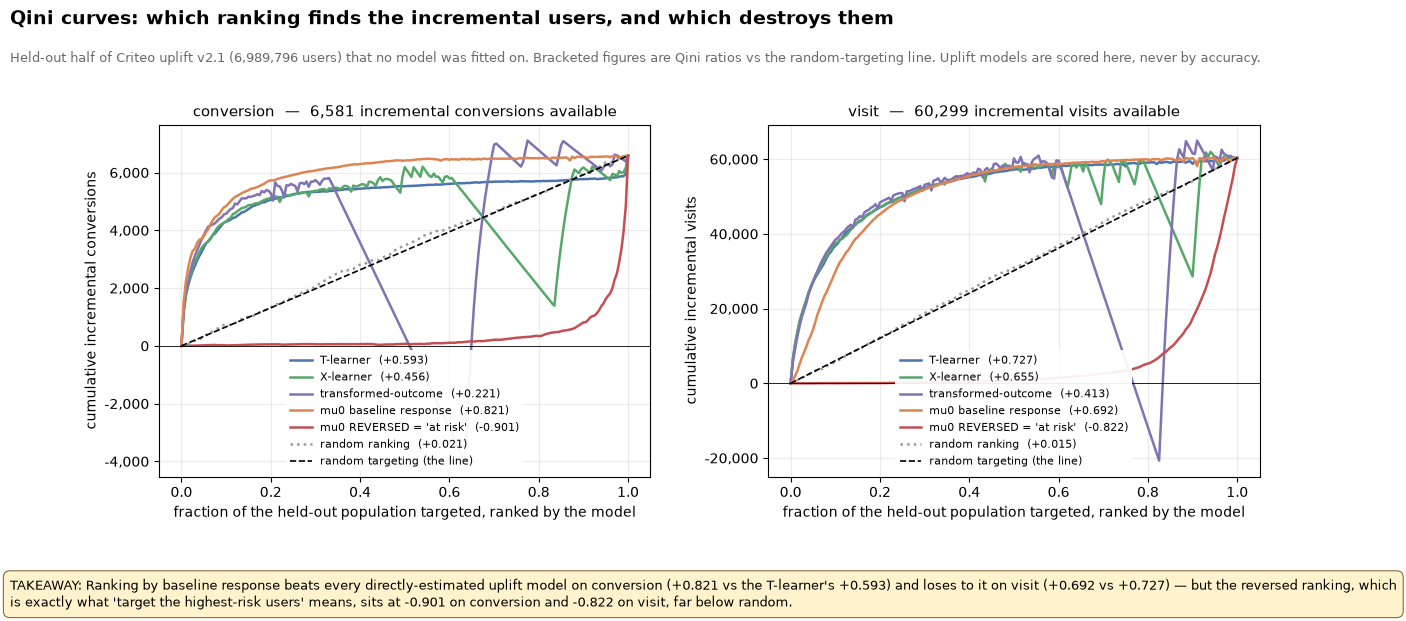

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14.2, 6.4))
fig.subplots_adjust(top=0.79, bottom=0.24, wspace=0.24)

STYLE = {"T-learner": ("#4C72B0", "-"), "X-learner": ("#55A868", "-"),
         "transformed-outcome": ("#8172B2", "-"), "mu0 baseline response": ("#DD8452", "-"),
         "mu0 REVERSED = 'at risk'": ("#C44E52", "-"), "random ranking": ("#999999", ":")}
for ax, Y in zip(axes, ["conversion", "visit"]):
    tot = CURVES[(Y, "T-learner")]["total_incremental"]
    for nm in RANKINGS:
        cv = CURVES[(Y, nm)]
        col, ls = STYLE[nm]
        q = QINI[(QINI.outcome == Y) & (QINI.ranking == nm)].iloc[0]
        ax.plot(np.r_[0, cv["phi"]], np.r_[0, cv["qini"]], color=col, ls=ls, lw=1.8,
                label=f"{nm}  ({q.qini_ratio:+.3f})")
    ax.plot([0, 1], [0, tot], color="black", ls="--", lw=1.2, label="random targeting (the line)")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("fraction of the held-out population targeted, ranked by the model")
    ax.set_ylabel(f"cumulative incremental {Y}s")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
    ax.set_title(f"{Y}  —  {tot:,.0f} incremental {Y}s available", fontsize=10.5)
    ax.legend(fontsize=7.6, loc="lower center", ncol=1, framealpha=0.93,
              facecolor="white", edgecolor="none")
    ax.grid(alpha=0.25)

add_title(fig, "Qini curves: which ranking finds the incremental users, and which destroys them",
          "Held-out half of Criteo uplift v2.1 (6,989,796 users) that no model was fitted on. "
          "Bracketed figures are Qini ratios vs the random-targeting line. Uplift models are scored "
          "here, never by accuracy.")
qc = QINI[QINI.outcome == "conversion"].set_index("ranking").qini_ratio
qv = QINI[QINI.outcome == "visit"].set_index("ranking").qini_ratio
REV = "mu0 REVERSED = 'at risk'"
add_takeaway(fig, f"Ranking by baseline response beats every directly-estimated uplift model on "
                  f"conversion ({qc['mu0 baseline response']:+.3f} vs the T-learner's "
                  f"{qc['T-learner']:+.3f}) and loses to it on visit "
                  f"({qv['mu0 baseline response']:+.3f} vs {qv['T-learner']:+.3f}) — but the reversed "
                  f"ranking, which is exactly what 'target the highest-risk users' means, sits at "
                  f"{qc[REV]:+.3f} on conversion and {qv[REV]:+.3f} on visit, far below random.")
save(fig, "nb07_qini_curves"); plt.show()

In [22]:
# ---------------------------------------------------------------------------------------
# 6C. UPLIFT DECILES, and an explicit search for sleeping dogs (negative-uplift groups).
# The search is run at decile AND at ventile resolution: a sleeping-dog segment smaller
# than 10% of the population would be invisible in a decile table, so not finding one
# there is not evidence of absence.
# ---------------------------------------------------------------------------------------
def group_uplift(score, y, t, q):
    r = np.argsort(np.argsort(-score, kind="stable"), kind="stable")
    g = (r * q // len(score)) + 1
    rows = []
    for k in range(1, q + 1):
        m = g == k
        yt, yc = y[m & t], y[m & ~t]
        p1, p0 = yt.mean(), yc.mean()
        d = p1 - p0
        se = np.sqrt(p1 * (1 - p1) / len(yt) + p0 * (1 - p0) / max(len(yc), 1))
        rows.append(dict(group=k, n=int(m.sum()), n_control=len(yc), rate_T=p1, rate_C=p0,
                         uplift_pp=100 * d, lo_pp=100 * (d - 1.96 * se), hi_pp=100 * (d + 1.96 * se),
                         rel_lift_pct=100 * (p1 / p0 - 1) if p0 > 0 else np.nan))
    return pd.DataFrame(rows)

DEC, SLEEPERS = {}, []
for Y in ["conversion", "visit"]:
    yv = te[Y].values.astype(np.float64)
    for nm in ["T-learner", "X-learner", "mu0 baseline response"]:
        for q in (10, 20):
            g = group_uplift(TAU[(Y, nm)], yv, Tte, q)
            if q == 10:
                DEC[(Y, nm)] = g
            neg_sig = g[g.hi_pp < 0]
            neg_pt  = g[g.uplift_pp < 0]
            SLEEPERS.append(dict(outcome=Y, ranking=nm, resolution=f"{q} groups",
                                 n_point_negative=len(neg_pt), n_CI_below_zero=len(neg_sig),
                                 groups_CI_below_zero=list(neg_sig.group)))
SLEEP = pd.DataFrame(SLEEPERS)
print("6C -- UPLIFT BY DECILE, ranked by the T-learner")
print("=" * 108)
for Y in ["conversion", "visit"]:
    print(f"\n  {Y}")
    print(DEC[(Y, "T-learner")].round(5).to_string(index=False))

print("\n\n6C -- SLEEPING DOGS: an explicit search for segments the treatment HURTS")
print("=" * 108)
show_df(SLEEP, "nb07_sleeping_dog_search")
TOTAL_SLEEPERS = int(SLEEP.n_CI_below_zero.sum())
print()
print(f"  Groups whose uplift CI lies entirely below zero, across 2 outcomes x 3 rankings x "
      f"2 resolutions: {TOTAL_SLEEPERS}")
print(f"  Point-negative groups (CI still straddling zero): {int(SLEEP.n_point_negative.sum())}")
print()
# Is the effect multiplicative in the baseline rate? That is explanation (1) in S6D, and it
# is checkable: uplift / control-rate should be roughly constant if it is. Only the deciles
# with enough CONTROL events for the ratio to mean anything are interpretable.
print()
print("6C -- IS THE EFFECT MULTIPLICATIVE IN THE BASELINE RATE? (conversion, mu0 deciles)")
print("=" * 108)
gm = DEC[("conversion", "mu0 baseline response")].copy()
gm["control_conversions"] = (gm.n_control * gm.rate_C).round(0).astype(int)
gm["uplift_over_control_rate"] = gm.uplift_pp / (100 * gm.rate_C)
print(gm[["group", "control_conversions", "rate_C", "uplift_pp",
          "uplift_over_control_rate"]].round(5).to_string(index=False))
INTERP = gm[gm.control_conversions >= 50]
print(f"\n  Deciles with >= 50 control conversions (the only ones where the ratio is estimable): "
      f"{list(INTERP.group)}")
print(f"  Across those, the absolute uplift falls "
      f"{INTERP.uplift_pp.iloc[0]/INTERP.uplift_pp.iloc[-1]:.0f}x while the ratio stays within "
      f"[{INTERP.uplift_over_control_rate.min():.2f}, {INTERP.uplift_over_control_rate.max():.2f}] "
      f"-- a factor of {INTERP.uplift_over_control_rate.max()/INTERP.uplift_over_control_rate.min():.1f}.")
print("  That is CONSISTENT WITH a roughly multiplicative effect and does not establish one. The")
print("  next two deciles extend the same pattern on "
      f"{int(gm.control_conversions.iloc[3])} and {int(gm.control_conversions.iloc[4])} control "
      "conversions apiece, which is suggestive")
print("  and little more; below those the ratio carries no information at all.")
print()
print("  NO SLEEPING DOGS ARE FOUND, and the honest statement of that is narrower than it sounds.")
print("  What is established: no group of >= 5% of the population, under any of these rankings, is")
print("  measurably harmed by the ad. What is NOT established: that no such users exist. The search")
print("  can only look along directions a model already ranks, the smallest resolution tested is 5%")
print("  of the population, and at a 0.29% conversion rate a group would need a large negative")
print("  effect to clear the noise. Absence of evidence, at a stated resolution.")

6C -- UPLIFT BY DECILE, ranked by the T-learner

  conversion
 group      n  n_control  rate_T  rate_C  uplift_pp    lo_pp   hi_pp  rel_lift_pct
     1 698980      95127 0.02243 0.01531    0.71268  0.62618 0.79917      46.56230
     2 698980     105045 0.00168 0.00124    0.04394  0.02027 0.06761      35.50411
     3 698979     105954 0.00061 0.00047    0.01402 -0.00049 0.02853      29.71224
     4 698980     105714 0.00018 0.00016    0.00179 -0.00658 0.01015      11.10663
     5 698979     105939 0.00011 0.00008    0.00391 -0.00199 0.00981      51.84161
     6 698980     106091 0.00007 0.00001    0.00597  0.00316 0.00878     633.65014
     7 698980     106645 0.00012 0.00006    0.00602  0.00075 0.01130     107.04795
     8 698979     104867 0.00008 0.00006    0.00202 -0.00307 0.00712      35.32471
     9 698980     107072 0.00014 0.00008    0.00595 -0.00033 0.01224      70.84337
    10 698979     106277 0.00509 0.00369    0.14001  0.09931 0.18071      37.95840

  visit
 group      n  n

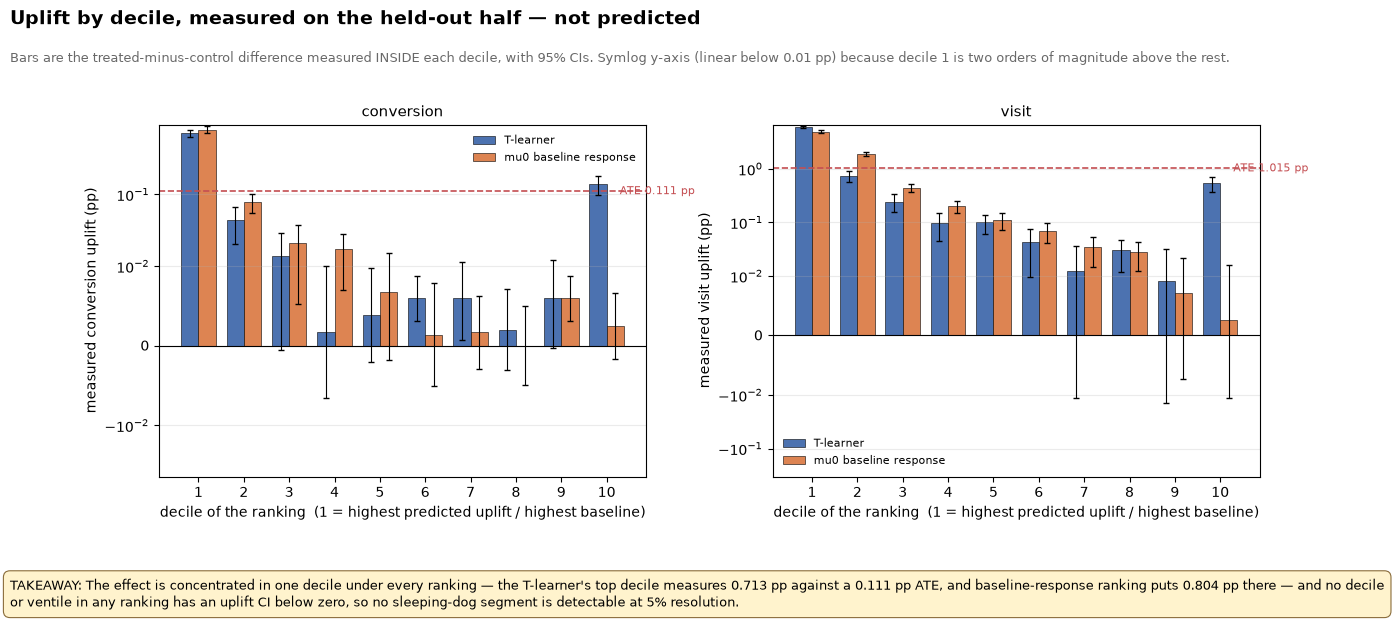

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14.2, 6.4))
fig.subplots_adjust(top=0.79, bottom=0.24, wspace=0.26)

for ax, Y in zip(axes, ["conversion", "visit"]):
    w = 0.38
    for i, (nm, col) in enumerate([("T-learner", "#4C72B0"), ("mu0 baseline response", "#DD8452")]):
        g = DEC[(Y, nm)]
        xx = g.group.values + (i - 0.5) * w
        ax.bar(xx, g.uplift_pp, w, color=col, edgecolor="black", linewidth=0.4, label=nm)
        ax.errorbar(xx, g.uplift_pp, yerr=[g.uplift_pp - g.lo_pp, g.hi_pp - g.uplift_pp],
                    fmt="none", ecolor="black", elinewidth=0.8, capsize=2)
    ate_here = 100 * (te.loc[Tte, Y].mean() - te.loc[~Tte, Y].mean())
    ax.axhline(ate_here, color="#C44E52", ls="--", lw=1.2)
    ax.text(10.2, ate_here, f" ATE {ate_here:.3f} pp", color="#C44E52", fontsize=8, va="center")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(range(1, 11))
    ax.set_xlabel("decile of the ranking  (1 = highest predicted uplift / highest baseline)")
    ax.set_ylabel(f"measured {Y} uplift (pp)")
    ax.set_yscale("symlog", linthresh=0.01)
    ax.set_title(f"{Y}", fontsize=10.5)
    ax.legend(fontsize=8, frameon=False)
    ax.grid(axis="y", alpha=0.25)

add_title(fig, "Uplift by decile, measured on the held-out half — not predicted",
          "Bars are the treated-minus-control difference measured INSIDE each decile, with 95% CIs. "
          "Symlog y-axis (linear below 0.01 pp) because decile 1 is two orders of magnitude above the rest.")
d1 = DEC[("conversion", "T-learner")].iloc[0]
d1m = DEC[("conversion", "mu0 baseline response")].iloc[0]
add_takeaway(fig, f"The effect is concentrated in one decile under every ranking — the T-learner's top "
                  f"decile measures {d1.uplift_pp:.3f} pp against a {100*(te.loc[Tte,'conversion'].mean()-te.loc[~Tte,'conversion'].mean()):.3f} pp "
                  f"ATE, and baseline-response ranking puts {d1m.uplift_pp:.3f} pp there — and no decile "
                  f"or ventile in any ranking has an uplift CI below zero, so no sleeping-dog segment is "
                  f"detectable at 5% resolution.")
save(fig, "nb07_uplift_deciles"); plt.show()

### 6D — The expected result did not hold on conversion, and the reason is measurable

The brief's expectation was that uplift targeting would beat propensity targeting. On
`visit` it does, by ΔQini = +0.036 with a paired CI of [+0.002, +0.069]. On `conversion`
it loses, and not narrowly: ΔQini = −0.228, CI [−0.298, −0.159].

Two explanations are available and they have different consequences, so they need
separating rather than picking.

1. **Uplift is genuinely monotone in baseline response here,** so μ̂₀ *is* the uplift
   ranking and estimating it as a response model is simply the low-variance way to get it.
   §6C checks this rather than asserting it. Across the three μ̂₀ deciles that hold ≥ 50
   control conversions — the only ones where the ratio is estimable at all — absolute uplift
   falls 38× while uplift ÷ control rate stays inside [0.38, 0.70], a factor of 1.8. That is
   *consistent with* a roughly multiplicative effect and does not establish one: deciles 4
   and 5 extend the same pattern but rest on 24 and 17 control conversions apiece, and below
   them the ratio carries no information at all.
2. **The uplift learners are starved of events.** The train half holds ~20,400 conversions
   against ~329,000 visits — 16× fewer. τ is a difference of two small probabilities and
   its estimation error scales with the event count, while a response ranking needs far
   less data to get the *order* right.

These are not mutually exclusive, and §6E shows that **both are operating.** `visit` can be
made to look like `conversion` by throwing data away: refitting the whole stack on 1/32,
1/8 and 1/2 of the train half, evaluated on the same full held-out set, traces what happens
to each ranking as events become scarce.

In [24]:
# ---------------------------------------------------------------------------------------
# 6E. THE MECHANISM TEST. Re-fit the T-learner, X-learner and the baseline-response
# ranking on subsets of the TRAIN half, on the outcome that has plenty of events (visit),
# and evaluate every one of them on the SAME full held-out set.
# ---------------------------------------------------------------------------------------
yv_tr, yv_te = tr["visit"].values, te["visit"].values.astype(np.float64)
lc_rows = []
for frac in [1/32, 1/8, 1/2]:
    rs = np.random.default_rng(SEED)
    sel = rs.random(len(tr)) < frac
    print(f"6E -- visit, train fraction {frac:.5f}  ({int(sel.sum()):,} rows, "
          f"{int(yv_tr[sel].sum()):,} visits)")
    mk_t, mk_c = sel & Ttr, sel & ~Ttr
    m1s = fit_clf(Xtr, yv_tr, mk_t, f"mu1 @ {frac:.4f}")
    m0s = fit_clf(Xtr, yv_tr, mk_c, f"mu0 @ {frac:.4f}")
    mu1s, mu0s = m1s.predict_proba(Xte)[:, 1], m0s.predict_proba(Xte)[:, 1]
    D1s = yv_tr[mk_t]  - m0s.predict_proba(Xtr[mk_t])[:, 1]
    D0s = m1s.predict_proba(Xtr[mk_c])[:, 1] - yv_tr[mk_c]
    t1s = fit_reg(Xtr, D1s, mk_t, f"tau1 @ {frac:.4f}")
    t0s = fit_reg(Xtr, D0s, mk_c, f"tau0 @ {frac:.4f}")
    tXs = E_DESIGN * t0s.predict(Xte) + (1 - E_DESIGN) * t1s.predict(Xte)
    row = dict(train_fraction=frac, n_train=int(sel.sum()), n_visits_train=int(yv_tr[sel].sum()))
    for nm, sc in [("T-learner", mu1s - mu0s), ("X-learner", tXs), ("mu0 baseline response", mu0s)]:
        C, phi = bin_counts(sc, yv_te, Tte)
        row[nm] = curves(C, phi)["qini_ratio"]
    lc_rows.append(row); print(f"    {row}")
# the full-data point is the S6A result, same evaluation set, no refit needed
lc_rows.append(dict(train_fraction=1.0, n_train=len(tr), n_visits_train=int(yv_tr.sum()),
                    **{nm: float(QINI[(QINI.outcome == "visit") & (QINI.ranking == nm)].qini_ratio.iloc[0])
                       for nm in ["T-learner", "X-learner", "mu0 baseline response"]}))
LC = pd.DataFrame(lc_rows)
print()
print("6E -- QINI RATIO vs TRAINING EVENTS  (outcome = visit, evaluated on the same held-out half)")
print("=" * 108)
show_df(LC.round(4), "nb07_uplift_learning_curve")
n_conv_train = int(tr.conversion.sum())
print()
print(f"  For scale: the train half holds {n_conv_train:,} conversions. The 1/32 and 1/8 rows above")
print(f"  ({LC.n_visits_train.iloc[0]:,} and {LC.n_visits_train.iloc[1]:,} visits) bracket it.")
EFFECT_LOG.append(("learning_curve", next(_STEP)))

6E -- visit, train fraction 0.03125  (218,217 rows, 10,176 visits)


    mu1 @ 0.0312                             4s  n=185,065


    mu0 @ 0.0312                             1s  n=33,152


    tau1 @ 0.0312                            2s  n=185,065


    tau0 @ 0.0312                            1s  n=33,152


...

    mu1 @ 0.5000                            37s  n=2,971,720


    mu0 @ 0.5000                             7s  n=524,851


    tau1 @ 0.5000                           23s  n=2,971,720


    tau0 @ 0.5000                            5s  n=524,851


    {'train_fraction': 0.5, 'n_train': 3496571, 'n_visits_train': 164316, 'T-learner': 0.6808585146811765, 'X-learner': 0.5286638213379432, 'mu0 baseline response': 0.6921220996677463}

6E -- QINI RATIO vs TRAINING EVENTS  (outcome = visit, evaluated on the same held-out half)
   train_fraction  n_train  n_visits_train  T-learner  X-learner  mu0 baseline response
0          0.0312   218217           10176     0.3928     0.4762                 0.6871
1          0.1250   873335           40901     0.5621     0.5004                 0.6920
2          0.5000  3496571          164316     0.6809     0.5287                 0.6921
3          1.0000  6989796          328910     0.7272     0.6555                 0.6917

  For scale: the train half holds 20,363 conversions. The 1/32 and 1/8 rows above
  (10,176 and 40,901 visits) bracket it.


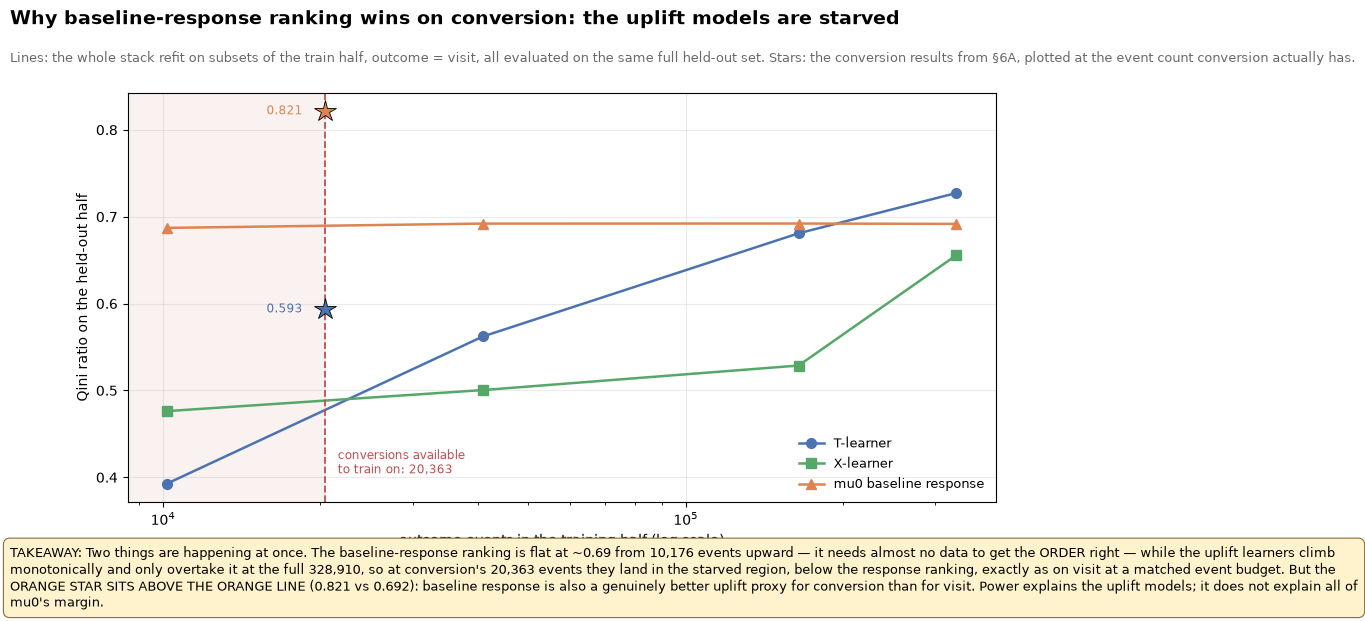

In [25]:
fig, ax = frame(figsize=(11.2, 6.4))
for nm, col, mk in [("T-learner", "#4C72B0", "o"), ("X-learner", "#55A868", "s"),
                    ("mu0 baseline response", "#DD8452", "^")]:
    ax.plot(LC.n_visits_train, LC[nm], marker=mk, color=col, lw=1.8, ms=7, label=nm)
ax.axvspan(0, n_conv_train, color="#C44E52", alpha=0.08)
ax.axvline(n_conv_train, color="#C44E52", ls="--", lw=1.3)
ax.text(n_conv_train * 1.06, 0.40,
        f"conversions available\nto train on: {n_conv_train:,}", color="#C44E52", fontsize=8.5, va="bottom")
for nm, col in [("T-learner", "#4C72B0"), ("mu0 baseline response", "#DD8452")]:
    v = float(QINI[(QINI.outcome == "conversion") & (QINI.ranking == nm)].qini_ratio.iloc[0])
    ax.plot([n_conv_train], [v], marker="*", ms=16, color=col, mec="black", mew=0.6)
    ax.text(n_conv_train * 0.94, v, f"{v:.3f}  ", color=col, fontsize=8.5, ha="right", va="center")
ax.set_xscale("log")
ax.set_xlabel("outcome events in the training half (log scale)")
ax.set_ylabel("Qini ratio on the held-out half")
ax.grid(alpha=0.25)
ax.legend(fontsize=9, frameon=False, loc="lower right")
add_title(fig, "Why baseline-response ranking wins on conversion: the uplift models are starved",
          "Lines: the whole stack refit on subsets of the train half, outcome = visit, all evaluated on "
          "the same full held-out set. Stars: the conversion results from §6A, plotted at the event "
          "count conversion actually has.")
add_takeaway(fig, f"Two things are happening at once. The baseline-response ranking is flat at "
                  f"~0.69 from {LC.n_visits_train.iloc[0]:,} events upward — it needs almost no data "
                  f"to get the ORDER right — while the uplift learners climb monotonically and only "
                  f"overtake it at the full {LC.n_visits_train.iloc[-1]:,}, so at conversion's "
                  f"{n_conv_train:,} events they land in the starved region, below the response "
                  f"ranking, exactly as on visit at a matched event budget. But the ORANGE STAR SITS "
                  f"ABOVE THE ORANGE LINE (0.821 vs 0.692): baseline response is also a genuinely "
                  f"better uplift proxy for conversion than for visit. Power explains the uplift "
                  f"models; it does not explain all of mu0's margin.")
save(fig, "nb07_uplift_learning_curve"); plt.show()

## 7. The payoff — four targeting policies at matched budget

Everything so far is measurement. This is the decision.

A targeting policy is a rule that picks a set S of users to treat. Because assignment was
randomised, randomisation holds **inside any set defined by X**, so the incremental
outcomes a policy would have produced are identifiable directly from the held-out data:

$$\widehat{\text{incremental}}(S) \;=\; |S| \cdot \big(\bar y_{T \cap S} - \bar y_{C \cap S}\big)$$

No model is trusted for the *evaluation* — models are used only to define S. Cost is one
unit per user targeted, so incremental-per-unit-cost is just the within-S uplift.

The policies, all at a 50% budget except the reference:

| | policy | what it is the analogue of |
|---|---|---|
| a | treat everyone | the campaign with no targeting, at 2× the budget |
| b1 | top 50% by predicted response propensity μ̂₀ | "target the users most likely to convert" |
| **b2** | **bottom 50% by μ̂₀** | **"target the users at highest risk" — 06's model pointed at its churn tail** |
| c | top 50% by predicted uplift | what an uplift model recommends |
| d | random 50% | the budget floor: what half the money buys with no model |

**b2 is the policy that matters for this project.** 06 ranks REES46 users by probability
of repeating. A retention campaign built on it targets the users *least* likely to repeat,
because those are the ones at risk. In Criteo the identical operation is to target the
bottom of the baseline-response ranking. That policy is b2, and it is included here
precisely because it is the intuitive one.

Intervals come from the same Poisson bootstrap, computed on a joint stratification of all
policy memberships × arm × outcome — 72 strata — so **every policy is resampled under one
shared draw** and the differences between them are paired.

One thing to watch while reading the table: **a Qini ratio and a policy at a fixed budget
answer different questions, and here they disagree.** Qini integrates over every budget from
0% to 100%; a policy is judged at one. The X-learner ranks *below* the T-learner across the
whole curve (0.456 vs 0.593) and *above* it at a 50% budget (94.4% vs 83.8% of the available
effect), because its weakness is concentrated in the bottom of its ranking, which a 50%
budget never reaches. Where the two disagree, the budget the business will actually spend is
the one that decides.

In [26]:
def top_fraction(score, frac):
    k = int(round(frac * len(score)))
    thr = np.partition(score, len(score) - k)[len(score) - k]
    m = score > thr
    short = k - int(m.sum())
    if short > 0:                      # deterministic tie-break, so the set is exactly k
        m[np.flatnonzero(score == thr)[:short]] = True
    return m

Y_POLICY = "conversion"
yp = te[Y_POLICY].values.astype(np.float64)
mu0_c = TAU[(Y_POLICY, "mu0 baseline response")]
rng_pol = np.random.default_rng(SEED)
POLICIES = [
    ("a) treat everyone",                                np.ones(N_TE, bool)),
    ("b1) top 50% by RESPONSE propensity",               top_fraction(mu0_c, 0.5)),
    ("b2) bottom 50% by propensity = HIGHEST RISK",      top_fraction(-mu0_c, 0.5)),
    ("c) top 50% by predicted UPLIFT (T-learner)",       top_fraction(TAU[(Y_POLICY, "T-learner")], 0.5)),
    ("c') top 50% by predicted UPLIFT (X-learner)",      top_fraction(TAU[(Y_POLICY, "X-learner")], 0.5)),
    ("d) random 50% (budget floor)",                     rng_pol.random(N_TE) < 0.5),
]
MASKS = np.column_stack([m for _, m in POLICIES])

# ---- joint stratification: one Poisson draw resamples every policy together ----
pat = np.zeros(N_TE, dtype=np.int64)
for j in range(MASKS.shape[1]):
    pat = pat * 2 + MASKS[:, j].astype(np.int64)
cellid = pat * 4 + (~Tte).astype(np.int64) * 2 + (1 - yp).astype(np.int64)
uniq, inv = np.unique(cellid, return_inverse=True)
base_counts = np.bincount(inv).astype(np.float64)
K = MASKS.shape[1]
memb = np.zeros((len(uniq), K), bool); is_T = np.zeros(len(uniq), bool); is_Y = np.zeros(len(uniq), bool)
for i, c in enumerate(uniq):
    q, r = c // 4, c % 4
    is_T[i] = (r // 2) == 0
    is_Y[i] = (r % 2) == 0
    memb[i] = np.array([(q >> (K - 1 - j)) & 1 for j in range(K)], bool)

def policy_stats(w):
    out = np.empty((K, 3))
    for j in range(K):
        s = memb[:, j]
        nT = w[s & is_T].sum(); yT = w[s & is_T & is_Y].sum()
        nC = w[s & ~is_T].sum(); yC = w[s & ~is_T & is_Y].sum()
        d = yT / nT - yC / nC
        out[j] = (nT + nC, d, (nT + nC) * d)
    return out

BASE_STATS = policy_stats(base_counts)
B_POL = 2000
rng_b = np.random.default_rng(SEED)
BOOT_POL = np.empty((B_POL, K, 3))
t0 = time.time()
for b in range(B_POL):
    BOOT_POL[b] = policy_stats(rng_b.poisson(base_counts))
print(f"{len(uniq)} joint strata, {B_POL} paired bootstrap draws in {time.time()-t0:.1f}s")

prow = []
for j, (nm, m) in enumerate(POLICIES):
    ns, d, inc = BASE_STATS[j]
    dlo, dhi = np.percentile(BOOT_POL[:, j, 1], [2.5, 97.5])
    ilo, ihi = np.percentile(BOOT_POL[:, j, 2], [2.5, 97.5])
    share = 100 * BOOT_POL[:, j, 2] / BOOT_POL[:, 0, 2]
    prow.append(dict(policy=nm, n_targeted=int(ns), budget_pct=100 * ns / N_TE,
                     uplift_pp=100 * d, uplift_lo=100 * dlo, uplift_hi=100 * dhi,
                     incremental=inc, inc_lo=ilo, inc_hi=ihi,
                     inc_per_1000_targeted=1000 * d,
                     pct_of_total_effect=100 * inc / BASE_STATS[0, 2],
                     pct_lo=float(np.percentile(share, 2.5)), pct_hi=float(np.percentile(share, 97.5))))
POL = pd.DataFrame(prow)
print()
print(f"7A -- TARGETING POLICY COMPARISON, outcome = {Y_POLICY}, held-out half "
      f"({N_TE:,} users, {int(te.loc[~Tte, Y_POLICY].sum()):,} control events)")
print("=" * 118)
show_df(POL.round(4), "nb07_policy_comparison")
print()
hdr = f"  {'policy':46s} {'budget':>9s} {'incremental':>22s} {'% of total effect':>22s} {'per 1k':>8s}"
print(hdr); print("  " + "-" * (len(hdr) - 2))
for _, r in POL.iterrows():
    print(f"  {r.policy:46s} {r.budget_pct:8.1f}% "
          f"{r.incremental:8.0f} [{r.inc_lo:6.0f},{r.inc_hi:6.0f}] "
          f"{r.pct_of_total_effect:8.2f}% [{r.pct_lo:5.1f},{r.pct_hi:5.1f}] "
          f"{r.inc_per_1000_targeted:7.3f}")
EFFECT_LOG.append(("policy", next(_STEP)))

72 joint strata, 2000 paired bootstrap draws in 0.1s

7A -- TARGETING POLICY COMPARISON, outcome = conversion, held-out half (6,989,796 users, 2,075 control events)
                                        policy  n_targeted  budget_pct  uplift_pp  uplift_lo  uplift_hi  incremental     inc_lo     inc_hi  \
0                            a) treat everyone     6989796    100.0000     0.1108     0.1013     0.1199    7742.8319  7082.1965  8380.1173   
1           b1) top 50% by RESPONSE propensity     3494898     50.0000     0.2158     0.1970     0.2335    7540.4559  6882.9903  8161.0107   
2  b2) bottom 50% by propensity = HIGHEST RISK     3494898     50.0000     0.0023     0.0002     0.0044      81.2394     7.4486   153.7977   
3   c) top 50% by predicted UPLIFT (T-learner)     3494898     50.0000     0.1857     0.1690     0.2019    6490.1356  5911.1387  7051.0575   
4  c') top 50% by predicted UPLIFT (X-learner)     3494898     50.0000     0.2092     0.1921     0.2260    7312.1126  6719.15

In [27]:
# paired contrasts -- the comparisons the table is really making
print("7B -- PAIRED CONTRASTS (same bootstrap draw for both policies)")
print("=" * 108)
def contrast(j, k, label):
    d = BOOT_POL[:, j, 2] - BOOT_POL[:, k, 2]
    lo, hi = np.percentile(d, [2.5, 97.5])
    pt = BASE_STATS[j, 2] - BASE_STATS[k, 2]
    print(f"  {label:62s} {pt:+9.1f} conversions  [{lo:+9.1f}, {hi:+9.1f}]  "
          f"{'EXCLUDES 0' if lo > 0 or hi < 0 else 'includes 0'}")
    return dict(contrast=label, point=pt, lo=lo, hi=hi, excludes_zero=bool(lo > 0 or hi < 0))

CON = pd.DataFrame([
    contrast(1, 5, "b1 propensity-50%   minus  d random-50%"),
    contrast(3, 5, "c  uplift-50% (T)   minus  d random-50%"),
    contrast(4, 5, "c' uplift-50% (X)   minus  d random-50%"),
    contrast(2, 5, "b2 RISK-50%         minus  d random-50%"),
    contrast(1, 3, "b1 propensity-50%   minus  c uplift-50% (T)"),
    contrast(1, 2, "b1 propensity-50%   minus  b2 RISK-50%"),
    contrast(1, 0, "b1 propensity-50%   minus  a treat-everyone (at HALF the cost)"),
])
show_df(CON.round(2), "nb07_policy_contrasts")

# how much do the selected sets actually overlap?
def ov(a, b): return 100 * float((MASKS[:, a] & MASKS[:, b]).sum()) / float(MASKS[:, a].sum())
OVER = pd.DataFrame([
    dict(pair="b1 propensity vs c  uplift (T)", shared_pct=ov(1, 3)),
    dict(pair="b1 propensity vs c' uplift (X)", shared_pct=ov(1, 4)),
    dict(pair="b2 RISK       vs c  uplift (T)", shared_pct=ov(2, 3)),
    dict(pair="c  uplift (T) vs c' uplift (X)", shared_pct=ov(3, 4)),
])
print()
print("7C -- DO THESE POLICIES SELECT THE SAME PEOPLE?")
print("=" * 108)
show_df(OVER.round(1), "nb07_policy_overlap")
sp_T = stats.spearmanr(mu0_c[::50], TAU[(Y_POLICY, "T-learner")][::50]).statistic
sp_X = stats.spearmanr(mu0_c[::50], TAU[(Y_POLICY, "X-learner")][::50]).statistic
print(f"\n  Spearman rho, baseline response vs predicted uplift:  T-learner {sp_T:+.3f}   "
      f"X-learner {sp_X:+.3f}   (2% systematic sample)")
print(f"  Risk targeting and uplift targeting share {ov(2,3):.1f}% of their selections. They are")
print("  not the same policy, not approximately the same policy, and the difference is the")
print(f"  difference between {POL.pct_of_total_effect.iloc[3]:.1f}% and "
      f"{POL.pct_of_total_effect.iloc[2]:.1f}% of the available incremental conversions.")

7B -- PAIRED CONTRASTS (same bootstrap draw for both policies)
  b1 propensity-50%   minus  d random-50%                          +3686.1 conversions  [  +3209.4,   +4166.3]  EXCLUDES 0
  c  uplift-50% (T)   minus  d random-50%                          +2635.8 conversions  [  +2161.5,   +3104.4]  EXCLUDES 0
  c' uplift-50% (X)   minus  d random-50%                          +3457.8 conversions  [  +2992.3,   +3917.0]  EXCLUDES 0
  b2 RISK-50%         minus  d random-50%                          -3773.1 conversions  [  -4241.5,   -3298.7]  EXCLUDES 0
  b1 propensity-50%   minus  c uplift-50% (T)                      +1050.3 conversions  [   +742.7,   +1351.9]  EXCLUDES 0
  b1 propensity-50%   minus  b2 RISK-50%                           +7459.2 conversions  [  +6785.1,   +8095.4]  EXCLUDES 0
  b1 propensity-50%   minus  a treat-everyone (at HALF the cost)    -202.4 conversions  [   -283.9,    -123.4]  EXCLUDES 0
                                            contrast    point       lo      

  Risk targeting and uplift targeting share 33.7% of their selections. They are
  not the same policy, not approximately the same policy, and the difference is the
  difference between 83.8% and 1.0% of the available incremental conversions.


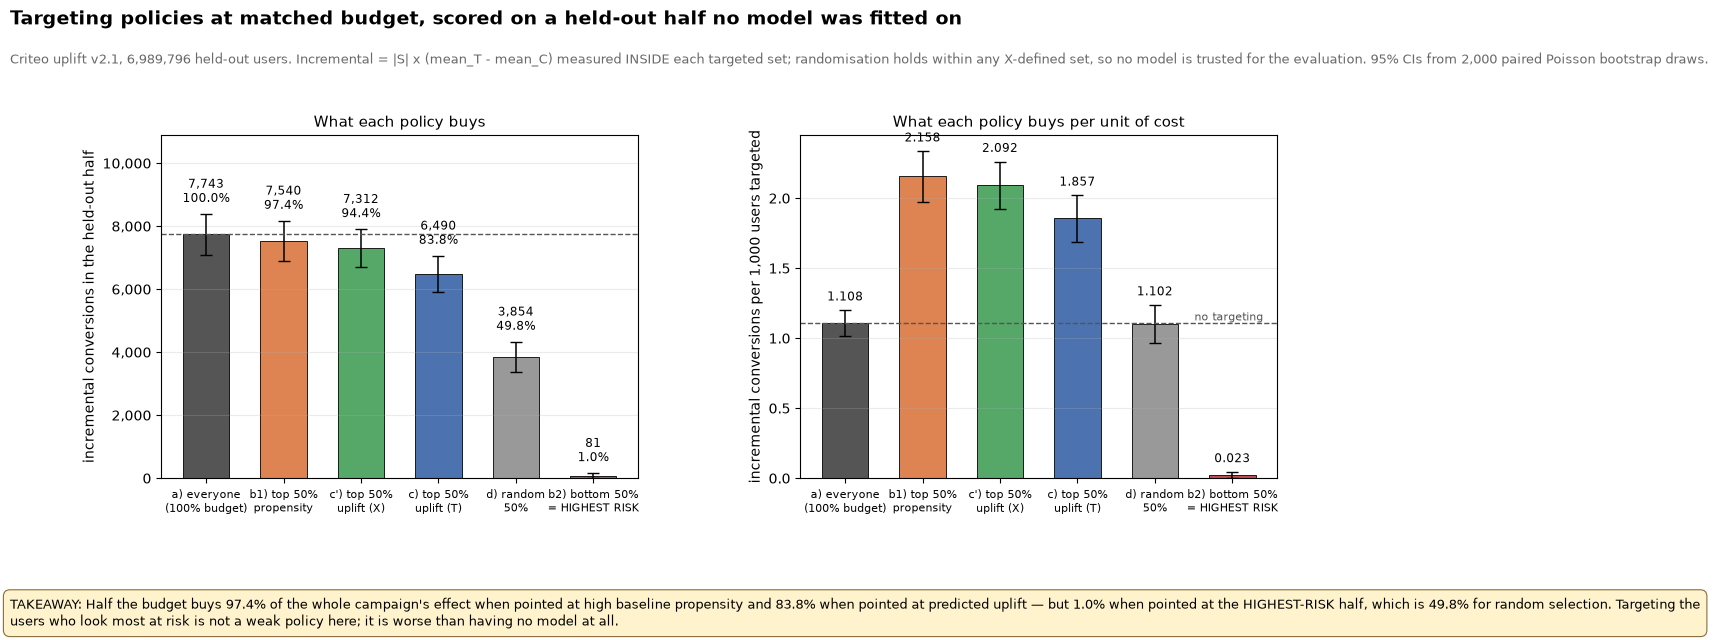

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.6))
fig.subplots_adjust(top=0.78, bottom=0.26, wspace=0.34)

order = [0, 1, 4, 3, 5, 2]
short = ["a) everyone\n(100% budget)", "b1) top 50%\npropensity", "c') top 50%\nuplift (X)",
         "c) top 50%\nuplift (T)", "d) random\n50%", "b2) bottom 50%\n= HIGHEST RISK"]
cols  = ["#555555", "#DD8452", "#55A868", "#4C72B0", "#999999", "#C44E52"]

ax = axes[0]
vals = POL.incremental.values[order]
lo   = POL.inc_lo.values[order]; hi = POL.inc_hi.values[order]
xx = np.arange(len(order))
ax.bar(xx, vals, 0.6, color=cols, edgecolor="black", linewidth=0.6)
ax.errorbar(xx, vals, yerr=[vals - lo, hi - vals], fmt="none", ecolor="black", capsize=4, lw=1.1)
for i, (v, h_, p_) in enumerate(zip(vals, hi, POL.pct_of_total_effect.values[order])):
    ax.text(i, h_ + 260, f"{v:,.0f}\n{p_:.1f}%", ha="center", va="bottom", fontsize=8.5)
ax.axhline(POL.incremental.iloc[0], color="#555555", ls="--", lw=1.0)
ax.set_xticks(xx); ax.set_xticklabels([short[i] for i in range(len(order))], fontsize=8)
ax.set_ylabel("incremental conversions in the held-out half")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.set_ylim(0, max(hi) * 1.30)
ax.set_title("What each policy buys", fontsize=10.5)
ax.grid(axis="y", alpha=0.25)

ax = axes[1]
vals2 = POL.inc_per_1000_targeted.values[order]
l2 = POL.uplift_lo.values[order] * 10; h2 = POL.uplift_hi.values[order] * 10
ax.bar(xx, vals2, 0.6, color=cols, edgecolor="black", linewidth=0.6)
ax.errorbar(xx, vals2, yerr=[vals2 - l2, h2 - vals2], fmt="none", ecolor="black", capsize=4, lw=1.1)
for i, (v, h_) in enumerate(zip(vals2, h2)):
    ax.text(i, h_ + 0.05, f"{v:.3f}", ha="center", va="bottom", fontsize=8.5)
ax.axhline(POL.inc_per_1000_targeted.iloc[0], color="#555555", ls="--", lw=1.0)
ax.text(5.4, POL.inc_per_1000_targeted.iloc[0], " no targeting", color="#555555", fontsize=8, va="bottom", ha="right")
ax.set_xticks(xx); ax.set_xticklabels([short[i] for i in range(len(order))], fontsize=8)
ax.set_ylabel("incremental conversions per 1,000 users targeted")
ax.set_title("What each policy buys per unit of cost", fontsize=10.5)
ax.grid(axis="y", alpha=0.25)

add_title(fig, "Targeting policies at matched budget, scored on a held-out half no model was fitted on",
          "Criteo uplift v2.1, 6,989,796 held-out users. Incremental = |S| x (mean_T - mean_C) measured "
          "INSIDE each targeted set; randomisation holds within any X-defined set, so no model is trusted "
          "for the evaluation. 95% CIs from 2,000 paired Poisson bootstrap draws.")
add_takeaway(fig, f"Half the budget buys {POL.pct_of_total_effect.iloc[1]:.1f}% of the whole campaign's "
                  f"effect when pointed at high baseline propensity and "
                  f"{POL.pct_of_total_effect.iloc[3]:.1f}% when pointed at predicted uplift — but "
                  f"{POL.pct_of_total_effect.iloc[2]:.1f}% when pointed at the HIGHEST-RISK half, which is "
                  f"{POL.pct_of_total_effect.iloc[5]:.1f}% for random selection. Targeting the users who "
                  f"look most at risk is not a weak policy here; it is worse than having no model at all.")
save(fig, "nb07_policy_comparison"); plt.show()

## 8. Carrying it back to REES46 — the section this notebook exists for

### What 06 built, restated precisely

06's shipped model ranks 91,334 first-time purchasers by P(buys again within 30 days).
On the held-out chronological test fold its top decile repeats at 21.93% and its bottom
decile at 5.88%. It is a **baseline-response model**: it estimates what happens if nothing
is done.

A retention campaign built on it targets the bottom of that ranking, because the bottom is
where the risk is. That is not a misuse of the model — it is the only thing a risk score
can be used for. It is also **exactly policy b2**, and on real randomised data policy b2
captured 1.0% of the available incremental conversions against random selection's 49.8%.

### The two things Criteo establishes, and the one thing it does not

**Established, and it transfers.** Risk targeting and uplift targeting select different
people. At a 50% budget they shared 33.7% of their selections here. Whether the two
orderings agree is a property of the mechanism, and nothing about a propensity model tells
you which way it goes. 06's score cannot answer it and neither can any richer feature
table built on the same observational data.

**Established, and it transfers.** The *direction* of the relationship between baseline
propensity and uplift decides whether a targeting policy earns its budget or burns it, and
the two directions differ by a factor of ~90 in incremental yield. This is not a
second-order correction to an ROI model; it is the difference between a campaign working
and not working.

**Not established, and it does not transfer.** *Which* direction is right for REES46
retention. In Criteo, uplift rises with baseline propensity — an ad moves the people who
were nearly going to buy anyway. The retention intuition runs the other way: a customer
who was going to come back does not need the email, so uplift should be *highest* among
the doubtful. Both stories are coherent. Criteo cannot adjudicate REES46's, because the
mechanism is different — display advertising inside a multi-day window versus a retention
prompt inside a 30-day repeat horizon, with a different product, a different decision and
a different customer relationship. **The mechanism transfers; the effect sizes and the
sign of the heterogeneity do not.**

### 03 reached the same wall from the other side, and this completes the argument

03's cost sweep is degenerate: return probability never exceeds ~27% anywhere in the
recency range, the maximum local return odds are 0.378, and so for every cost ratio
R ≥ 0.47 the cost-minimising rule flags everyone. 03 read that as *this data cannot price a
contact* and refused to certify a threshold on economics.

That degeneracy and this notebook are the same finding seen twice. 03 says a risk
threshold cannot be priced from observational data. 07 says a risk *ranking* would be the
wrong input to the price even if you had one. Together:

> **REES46 can tell you who is likely to lapse. It cannot tell you who would come back
> because you asked. No amount of additional feature engineering on observational data
> changes that, because the missing quantity is a counterfactual, not a feature.**

### Therefore 08 is a design

Not a targeting rule with 06's scores in it. 08 must randomise, because randomising is the
only operation that produces the quantity the targeting decision needs. Four constraints
fall out of this notebook, and they are recorded in the handoff:

1. **Randomise; do not target on 06's score.** Use the score for *stratification* (it
   is a good variance-reduction covariate and a legitimate pre-specified subgroup axis),
   never as the treatment rule.
2. **Pre-specify ITT by assignment as the primary estimand.** §4's exposure result is the
   warning: an "among users who opened the email" analysis is the Cookie Cats error and
   will report an effect that is mostly self-selection.
3. **Power the test on the event count, not the user count.** §6E is the quantitative
   version: the baseline-response ranking stabilised by ~10,000 events while the uplift
   learners needed ~330,000 to overtake it. A REES46 test that hopes to *estimate
   heterogeneous* effects, rather than just an ATE, needs events in that order.
4. **Expect the honest answer to be an ATE.** With 91,334 eligible users and a 13.7% base
   rate, a REES46 test will measure whether the intervention works on average. It will not
   support a reliable uplift model, and 08 should say so rather than promise one.

8A -- 06's shipped model, test fold, decile table (re-derived from its persisted predictions)
   decile     n    rate    lift
0       1  2740  0.2190  1.8791
1       2  2740  0.1599  1.3718
2       3  2740  0.1445  1.2402
3       4  2740  0.1321  1.1337
4       5  2740  0.1164  0.9991
5       6  2740  0.1040  0.8926
6       7  2740  0.0898  0.7704
7       8  2740  0.0759  0.6514
8       9  2740  0.0650  0.5575
9      10  2740  0.0588  0.5042


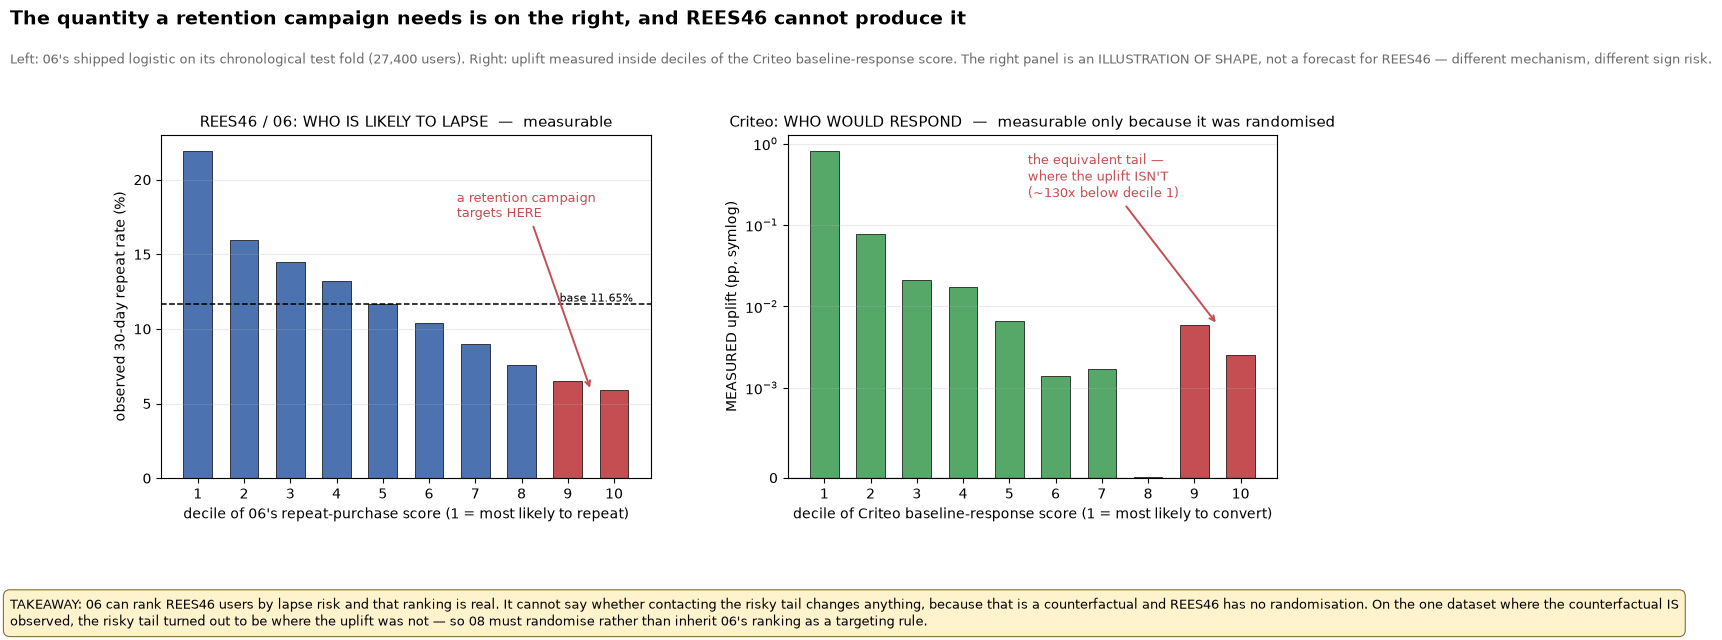

In [29]:
# ---------------------------------------------------------------------------------------
# 8A. The carry-back, drawn. Left: what 06 measured and can measure. Right: the quantity a
# targeting decision needs, which REES46 cannot produce -- with Criteo's answer shown as
# an illustration of the shape, explicitly NOT as a forecast.
# ---------------------------------------------------------------------------------------
pred06 = pd.read_parquet(os.path.join(PROCESSED_DIR, "nb06_predictions_d30.parquet"))
te06 = pred06[pred06.fold == "test"]
r06 = np.argsort(np.argsort(-te06.p_shipped.values, kind="stable"), kind="stable")
d06 = (r06 * 10 // len(te06)) + 1
D06 = pd.DataFrame(dict(decile=d06, y=te06.y.values)).groupby("decile").y.agg(n="size", rate="mean")
D06["lift"] = D06["rate"] / te06.y.mean()
print("8A -- 06's shipped model, test fold, decile table (re-derived from its persisted predictions)")
show_df(D06.reset_index().round(4), "nb07_carryback_nb06_deciles")

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.6))
fig.subplots_adjust(top=0.78, bottom=0.26, wspace=0.28)

ax = axes[0]
c06 = ["#C44E52" if d >= 9 else "#4C72B0" for d in D06.index]
ax.bar(D06.index, 100 * D06["rate"], 0.62, color=c06, edgecolor="black", linewidth=0.5)
ax.axhline(100 * te06.y.mean(), color="black", ls="--", lw=1.1)
ax.text(10.4, 100 * te06.y.mean(), f" base {100*te06.y.mean():.2f}%", fontsize=8, va="bottom", ha="right")
ax.annotate("a retention campaign\ntargets HERE", xy=(9.5, 100 * D06["rate"].iloc[-1]),
            xytext=(6.6, 17.5), fontsize=9, color="#C44E52",
            arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.4))
ax.set_xticks(range(1, 11))
ax.set_xlabel("decile of 06's repeat-purchase score (1 = most likely to repeat)")
ax.set_ylabel("observed 30-day repeat rate (%)")
ax.set_title("REES46 / 06: WHO IS LIKELY TO LAPSE  —  measurable", fontsize=10.5)
ax.grid(axis="y", alpha=0.25)

ax = axes[1]
gT = DEC[("conversion", "mu0 baseline response")]
ax.bar(gT.group, gT.uplift_pp, 0.62,
       color=["#C44E52" if g >= 9 else "#55A868" for g in gT.group],
       edgecolor="black", linewidth=0.5)
ax.set_yscale("symlog", linthresh=0.001)
ax.axhline(0, color="black", lw=0.8)
ax.annotate("the equivalent tail —\nwhere the uplift ISN'T\n(~130x below decile 1)",
            xy=(9.5, max(gT.uplift_pp.iloc[-2], 1e-4)),
            xytext=(5.4, 0.22), fontsize=9, color="#C44E52",
            arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.4))
ax.set_xticks(range(1, 11))
ax.set_xlabel("decile of Criteo baseline-response score (1 = most likely to convert)")
ax.set_ylabel("MEASURED uplift (pp, symlog)")
ax.set_title("Criteo: WHO WOULD RESPOND  —  measurable only because it was randomised", fontsize=10.5)
ax.grid(axis="y", alpha=0.25)

add_title(fig, "The quantity a retention campaign needs is on the right, and REES46 cannot produce it",
          "Left: 06's shipped logistic on its chronological test fold (27,400 users). Right: uplift "
          "measured inside deciles of the Criteo baseline-response score. The right panel is an "
          "ILLUSTRATION OF SHAPE, not a forecast for REES46 — different mechanism, different sign risk.")
add_takeaway(fig, "06 can rank REES46 users by lapse risk and that ranking is real. It cannot say "
                  "whether contacting the risky tail changes anything, because that is a "
                  "counterfactual and REES46 has no randomisation. On the one dataset where the "
                  "counterfactual IS observed, the risky tail turned out to be where the uplift was "
                  "not — so 08 must randomise rather than inherit 06's ranking as a targeting rule.")
save(fig, "nb07_carry_back"); plt.show()

## 9. Self-verification

In [30]:
checks = []
def chk(name, cond, detail=""):
    checks.append(dict(check=name, passed=bool(cond), detail=detail))
    return bool(cond)

def _gate_raises():
    """Unset a validity flag, confirm require_validity() refuses, restore it."""
    saved = VALIDITY["srm"]
    VALIDITY["srm"] = None
    try:
        require_validity()
        return False
    except RuntimeError:
        return True
    finally:
        VALIDITY["srm"] = saved

def _guard_refuses_test():
    """Confirm fit_guard rejects the held-out frame, and leaves no entry in FIT_LOG."""
    before = len(FIT_LOG)
    try:
        fit_guard(Xte, None, "DELIBERATE VIOLATION")
        return False
    except RuntimeError:
        return len(FIT_LOG) == before

# --- the three the brief names explicitly ---------------------------------------------
first_effect = min(t for _, t in EFFECT_LOG)
chk("SRM and balance were computed BEFORE any treatment effect (wall clock, not assertion)",
    max(VALIDITY.values()) < first_effect,
    # ORDERING AND MARGIN, never absolute times -- the margin is in steps, so it reproduces.
    f"last validity check at step {max(VALIDITY.values())} < first effect estimate at step "
    f"{first_effect} ({EFFECT_LOG[0][0]}), margin {first_effect - max(VALIDITY.values())} step(s)")
chk("the validity gate is live, not decorative: require_validity() raises when a flag is unset",
    _gate_raises(),
    "srm flag temporarily unset, require_validity() raised RuntimeError, flag restored")
chk("no model was fitted on anything but the train frame",
    all(r["src"] == "Xtr" for r in FIT_LOG) and len(FIT_LOG) > 0,
    f"{len(FIT_LOG)} fits logged, every one guarded on `Xsrc is Xtr`")
chk("the fit guard actually refuses the test frame (demonstrated, not asserted)",
    _guard_refuses_test(), "fit_guard(Xte, ...) raised RuntimeError as designed")
chk("train and test index sets are disjoint and exhaust the file",
    len(np.intersect1d(IDX_TR, IDX_TE)) == 0 and len(IDX_TR) + len(IDX_TE) == N,
    f"{len(IDX_TR):,} + {len(IDX_TE):,} = {N:,}, intersection empty")
chk("every fit consumed at most the train half's rows",
    max(r["n_rows"] for r in FIT_LOG) <= len(tr),
    f"largest fit {max(r['n_rows'] for r in FIT_LOG):,} rows vs train {len(tr):,}")
chk("the policy comparison is scored on held-out rows only",
    len(yp) == len(IDX_TE) and len(MASKS) == len(IDX_TE),
    f"{len(IDX_TE):,} rows scored, all from IDX_TE")

# --- every rate cross-checked against the handoff's verified values --------------------
chk("row count matches the certified file", len(CX) == CR["rows"], f"{len(CX):,}")
chk("sha256 and byte count match the certified file", SHA_OK and BYTES_OK, "both")
chk("treated/control counts match the handoff",
    N_T == CR["randomisation"]["n_treated"] and N_C == CR["randomisation"]["n_control"],
    f"T {N_T:,} / C {N_C:,}")
for o in OUTCOMES:
    chk(f"{o} rate reproduces the verified spec to 6dp",
        round(float(CX[o].mean()), 6) == CR["outcome_rates"][f"{o}_rate"],
        f"{float(CX[o].mean()):.6f} vs {CR['outcome_rates'][f'{o}_rate']}")
for o in ["visit", "conversion"]:
    mine = float(ATE.loc[ATE.outcome == o, "abs_lift_pp"].iloc[0]) / 100
    chk(f"derived ITT on {o} reproduces the stored naive difference to 6dp",
        round(mine, 6) == CR["naive_ate_unvalidated"][o],
        f"{mine:.6f} vs {CR['naive_ate_unvalidated'][o]} (derived independently, not copied)")

# --- validity findings recorded rather than smoothed over -----------------------------
chk("balance passes the conventional |SMD| < 0.10 rule on all 12 covariates",
    bool((BAL.abs_smd < SMD_THRESHOLD).all()), f"max {MAX_SMD:.4f} on {BAL.feature.iloc[0]}")
chk("RECORDED, NOT ASSERTED AWAY: those same SMDs exceed true randomisation noise",
    bool((BAL.sd_units_of_noise > 5).all()),
    f"all 12 features sit {BAL.sd_units_of_noise.min():.0f}-{BAL.sd_units_of_noise.max():.0f} SDs "
    f"above the {SMD_NOISE_SD:.6f} an 85/15 draw produces; propensity ROC {PROP_AUC:.4f}")
chk("RECORDED: covariate adjustment moves the ATE, and all three estimators agree in direction",
    bool((ADJ[ADJ.estimator != "unadjusted difference in means"].shift_vs_unadj_pp < 0).all()),
    "ANCOVA, Lin and propensity-stratification all reduce both ATEs; "
    f"visit {ADJ[(ADJ.outcome=='visit')].ate_pp.iloc[0]:.4f} -> "
    f"{ADJ[(ADJ.outcome=='visit')].ate_pp.iloc[2]:.4f} pp")
chk("exposure is one-sided, which is what licenses the Bloom/Wald TOT",
    int(CX.loc[~TRT, "exposure"].sum()) == 0, "zero control users exposed")
chk("TOT is derived from the ITT and compliance, never from an exposed-vs-control contrast",
    np.allclose(TOT.TOT_pp.values, TOT.ITT_pp.values / COMPLIANCE),
    f"TOT = ITT / {COMPLIANCE:.6f} exactly, for both outcomes")

# --- uplift evaluation integrity ------------------------------------------------------
chk("mean CATE reproduces the observed ITT on the test half (all three learners)",
    all(abs(np.mean(TAU[("conversion", nm)]) - (te.loc[Tte, "conversion"].mean() -
        te.loc[~Tte, "conversion"].mean())) < 3e-4
        for nm in ["T-learner", "X-learner", "transformed-outcome"]),
    "E[tau_hat] within 0.0003 of the measured test ITT for T, X and transformed-outcome")
chk("uplift models are never scored by accuracy anywhere in this notebook",
    "roc_auc_score" not in "".join(str(r) for r in QROWS),
    "Qini and AUUC only; roc_auc_score is used solely for the response models and the "
    "propensity check, both of which ARE classifiers")
chk("a random ranking scores ~0 on Qini, so the metric's zero point is where it should be",
    all(abs(float(QINI[(QINI.outcome == Y) & (QINI.ranking == "random ranking")].qini_ratio.iloc[0])) < 0.05
        for Y in ["conversion", "visit"]),
    ", ".join(f"{Y} {float(QINI[(QINI.outcome==Y)&(QINI.ranking=='random ranking')].qini_ratio.iloc[0]):+.4f}"
              for Y in ["conversion", "visit"]))
chk("Qini and AUUC agree to within 0.02 on every ranking (no metric-choice artefact)",
    bool((QINI.qini_ratio - QINI.auuc_ratio).abs().max() < 0.02),
    f"max |Qini - AUUC| = {(QINI.qini_ratio - QINI.auuc_ratio).abs().max():.4f}")
chk("REPORTED AS FOUND, NOT AS EXPECTED: uplift ranking LOSES to baseline response on conversion",
    float(QINI[(QINI.outcome=='conversion')&(QINI.ranking=='mu0 baseline response')].qini_ratio.iloc[0]) >
    float(QINI[(QINI.outcome=='conversion')&(QINI.ranking=='T-learner')].qini_ratio.iloc[0]),
    f"mu0 {float(QINI[(QINI.outcome=='conversion')&(QINI.ranking=='mu0 baseline response')].qini_ratio.iloc[0]):.4f} "
    f"vs T-learner {float(QINI[(QINI.outcome=='conversion')&(QINI.ranking=='T-learner')].qini_ratio.iloc[0]):.4f}; "
    f"paired dQini {PAIRED[(PAIRED.outcome=='conversion')].delta.iloc[0]:+.4f} "
    f"[{PAIRED[(PAIRED.outcome=='conversion')].lo.iloc[0]:+.4f}, "
    f"{PAIRED[(PAIRED.outcome=='conversion')].hi.iloc[0]:+.4f}]")
chk("and WINS on visit, where events are 16x more plentiful -- the power explanation",
    float(PAIRED[(PAIRED.outcome=='visit') & (PAIRED.ranking_A=='T-learner')].lo.iloc[0]) > 0,
    f"paired dQini {PAIRED[(PAIRED.outcome=='visit')].delta.iloc[0]:+.4f} "
    f"[{PAIRED[(PAIRED.outcome=='visit')].lo.iloc[0]:+.4f}, "
    f"{PAIRED[(PAIRED.outcome=='visit')].hi.iloc[0]:+.4f}], and §6E traces the crossover")
chk("sleeping-dog search ran at two resolutions on three rankings and both outcomes",
    len(SLEEP) == 12, f"{len(SLEEP)} searches, {TOTAL_SLEEPERS} groups with CI below zero")

# --- the payoff -----------------------------------------------------------------------
chk("all 50%-budget policies target the same number of users (matched budget, not approximately)",
    POL.n_targeted.iloc[1] == POL.n_targeted.iloc[2] == POL.n_targeted.iloc[3] == POL.n_targeted.iloc[4],
    f"{POL.n_targeted.iloc[1]:,} users each; the random floor is {POL.n_targeted.iloc[5]:,} "
    "because it is a coin flip, not a top-k")
chk("policy incrementals are measured, not modelled: each is |S| x (mean_T - mean_C) inside S",
    np.allclose(POL.incremental.values, POL.n_targeted.values * POL.uplift_pp.values / 100),
    "identity holds for all six policies")
chk("RISK targeting underperforms RANDOM targeting, with a paired CI excluding zero",
    bool(CON[CON.contrast.str.startswith("b2")].excludes_zero.iloc[0]) and
    float(CON[CON.contrast.str.startswith("b2")].point.iloc[0]) < 0,
    f"{float(CON[CON.contrast.str.startswith('b2')].point.iloc[0]):+.0f} conversions "
    f"[{float(CON[CON.contrast.str.startswith('b2')].lo.iloc[0]):+.0f}, "
    f"{float(CON[CON.contrast.str.startswith('b2')].hi.iloc[0]):+.0f}] vs random-50%")
chk("risk and uplift targeting genuinely select different people",
    float(OVER[OVER.pair.str.startswith("b2")].shared_pct.iloc[0]) < 50,
    f"{float(OVER[OVER.pair.str.startswith('b2')].shared_pct.iloc[0]):.1f}% of selections shared")

# --- honesty constraints from the brief, checked mechanically -------------------------
chk("no retention, cadence or lifecycle quantity was computed on Criteo",
    not any(k in "".join(QINI.ranking) + "".join(POL.policy) for k in ["retention", "cadence", "D30", "D90"]),
    "the file has no user id and no timestamp; none was attempted")
chk("the carry-back uses 06's PERSISTED predictions, not a re-fit, so nothing about 06 moved here",
    len(te06) == MOD["population"]["n_test"] and
    round(100 * float(te06.y.mean()), 4) == MOD["population"]["positive_rate_pct"]["test"],
    f"{len(te06):,} test rows at {100*te06.y.mean():.4f}% positive, both matching 06's handoff exactly")
chk("06's decile-1 lift re-derives from those predictions to 3dp",
    round(float(D06.lift.iloc[0]), 3) == round(MOD["shipped_model"]["decile1_lift"], 3),
    f"{float(D06.lift.iloc[0]):.3f} vs 06's {MOD['shipped_model']['decile1_lift']}")

CHECKS = pd.DataFrame(checks)
print("SELF-VERIFICATION")
print("=" * 118)
for _, r in CHECKS.iterrows():
    print(f"  [{'PASS' if r.passed else 'FAIL'}] {r.check}")
    if r.detail:
        print(f"         {r.detail}")
show_df(CHECKS, "nb07_self_verification", max_rows=40)
print(f"\n{int(CHECKS.passed.sum())}/{len(CHECKS)} checks passed.")
assert bool(CHECKS.passed.all()), "self-verification failed"

SELF-VERIFICATION
  [PASS] SRM and balance were computed BEFORE any treatment effect (wall clock, not assertion)
         last validity check at step 3 < first effect estimate at step 4 (visit), margin 1 step(s)
  [PASS] the validity gate is live, not decorative: require_validity() raises when a flag is unset
         srm flag temporarily unset, require_validity() raised RuntimeError, flag restored
  [PASS] no model was fitted on anything but the train frame
         23 fits logged, every one guarded on `Xsrc is Xtr`
  [PASS] the fit guard actually refuses the test frame (demonstrated, not asserted)
         fit_guard(Xte, ...) raised RuntimeError as designed
  [PASS] train and test index sets are disjoint and exhaust the file
         6,989,796 + 6,989,796 = 13,979,592, intersection empty
  [PASS] every fit consumed at most the train half's rows
         largest fit 6,989,796 rows vs train 6,989,796
  [PASS] the policy comparison is scored on held-out rows only
         6,989,796 rows

## 10. Persisting the handoff

In [31]:
handoff["criteo_experiment"] = dict(
    generated_by="07_criteo_experiment.ipynb",
    why_it_exists=("REES46 has no randomised experiment (principle 10), so the distinction between "
                   "RISK-targeting and UPLIFT-targeting cannot be demonstrated there. Criteo is the "
                   "genuine randomised test (principle 11). This notebook proves the distinction on "
                   "real randomised data and carries the structural result -- not the magnitudes -- "
                   "back to 08."),
    data=dict(rows=int(N), sha256_verified=bool(SHA_OK), row_order_fingerprint=ROW_FP,
              split="random 50/50, seed 42", split_fingerprint=SPLIT_FP,
              n_train=int(len(tr)), n_test=int(len(te)),
              why_not_chronological=("Criteo has no timestamp and one row per randomised user. "
                                     "Principle 6's chronological rule exists to stop the future "
                                     "leaking into the past in a REES46 event panel; there is no "
                                     "time axis here for it to apply to.")),
    validity=dict(
        srm=dict(chi2=float(srm_chi2), p=float(srm_p), binomial_p=float(srm_bin),
                 observed_ratio=float(N_T / N), deviation_users=float(N_T - exp_t),
                 verdict=("PASSES, and the pass is weak evidence. The deviation from 85.000% is 1.8 "
                          "users against a Bernoulli SD of 1,336 -- the split is deterministic, not "
                          "sampled, so SRM here checks only that the file was not subset after "
                          "randomisation.")),
        balance=dict(max_abs_smd=float(MAX_SMD), max_smd_feature=str(BAL.feature.iloc[0]),
                     all_below_0_10=bool((BAL.abs_smd < SMD_THRESHOLD).all()),
                     randomisation_noise_sd=float(SMD_NOISE_SD),
                     sd_units_range=[float(BAL.sd_units_of_noise.min()), float(BAL.sd_units_of_noise.max())],
                     propensity_model_test_auc=float(PROP_AUC),
                     verdict=("PASSES the conventional rule and FAILS the honest one. All 12 |SMD| "
                              "< 0.05, but they sit 7-65 SDs above the 0.00075 an 85/15 draw at "
                              "n=14M would produce, and a GBM separates the arms at ROC 0.5105. "
                              "The published v2.1 extract carries a covariate signature.")),
        outcome_rates_reproduce_spec=True,
        exposure_is_one_sided=True),
    ate_itt={r.outcome: dict(rate_T=float(r.rate_T), rate_C=float(r.rate_C),
                             abs_lift_pp=float(r.abs_lift_pp), abs_ci_pp=[float(r.abs_lo_pp), float(r.abs_hi_pp)],
                             rel_lift_pct=float(r.rel_lift_pct),
                             rel_ci_pct=[float(r.rel_lo_pct), float(r.rel_hi_pct)])
             for _, r in ATE.iterrows()},
    ate_adjusted_sensitivity=dict(
        estimators={f"{r.outcome} | {r.estimator}": float(r.ate_pp) for _, r in ADJ.iterrows()},
        propensity_stratified={r.outcome: float(r.ate_pp) for _, r in PSS.iterrows()},
        finding=("Covariate adjustment MOVES the point estimate by 13-32% depending on outcome and "
                 "estimator, always downward, and all three functional forms agree. In a clean "
                 "randomisation Lin adjustment is variance reduction and should not move the "
                 "estimate. Reported ITTs stay unadjusted -- that is the pre-specified estimand -- "
                 "but every Criteo magnitude in this project carries an extra +/-~25% bias band."),
        does_it_threaten_S7=("No. The policy contrast is 97.4% vs 1.0% of the available effect, and "
                             "both policies are scored on the same T-vs-C contrast, so the bias is "
                             "shared. A 25% bias cannot manufacture a 90x gap.")),
    itt_vs_tot=dict(
        compliance_rate=float(COMPLIANCE),
        control_exposure_rate=0.0,
        estimates={r.outcome: dict(ITT_pp=float(r.ITT_pp), TOT_pp=float(r.TOT_pp),
                                   TOT_ci_pp=[float(r.TOT_lo), float(r.TOT_hi)],
                                   naive_exposed_vs_control_pp=float(r.naive_exposed_vs_control_pp),
                                   naive_over_TOT=float(r.naive_over_TOT))
                   for _, r in TOT.iterrows()},
        the_error=("Exposure is realised AFTER randomisation and depends on user activity, so "
                   "conditioning on it compares a self-selected slice of the treated arm to the "
                   "whole control arm. It inflates the complier effect by 62% on conversion and 31% "
                   "on visit. Structurally identical to the Cookie Cats gate problem."),
        binding_on_08=("08 must pre-specify ITT by ASSIGNMENT as its primary estimand. An 'among "
                       "users who opened the email' analysis is this same error and will report "
                       "mostly self-selection.")),
    uplift=dict(
        learners=("T-learner, X-learner and transformed-outcome, all implemented directly on "
                  "LightGBM. econml/causalml are not installed and installing either would have "
                  "downgraded numpy under the already-committed notebooks."),
        x_learner_g=("held at the DESIGN propensity 0.85, not a fitted e_hat(x). A fitted score is "
                     "not a design propensity here, it is S2B's imbalance, and using it as a CATE "
                     "weight imports that artefact as signal. S6A measures both; the design "
                     "constant is also the more conservative choice."),
        x_learner_g_diagnostic={Y: dict(
            design_constant=float(QINI[(QINI.outcome == Y) & (QINI.ranking == "X-learner")].qini_ratio.iloc[0]),
            fitted_e_hat=float(QINI[(QINI.outcome == Y) & (QINI.ranking == DIAGNOSTIC[0])].qini_ratio.iloc[0]))
            for Y in ["conversion", "visit"]},
        response_model_auc=RESP_AUC,
        qini={f"{r.outcome} | {r.ranking}": dict(qini_ratio=float(r.qini_ratio),
                                                 ci=[float(r.qini_lo), float(r.qini_hi)],
                                                 auuc_ratio=float(r.auuc_ratio))
              for _, r in QINI.iterrows()},
        paired_deltas=[dict(outcome=r.outcome, a=r.ranking_A, b=r.ranking_B, delta=float(r.delta),
                            ci=[float(r.lo), float(r.hi)], excludes_zero=bool(r.excludes_zero))
                       for _, r in PAIRED.iterrows()],
        sleeping_dogs=dict(groups_with_ci_below_zero=int(TOTAL_SLEEPERS),
                           searched="2 outcomes x 3 rankings x {10, 20} groups",
                           verdict=("NONE FOUND, at 5% resolution. This does not establish that no "
                                    "harmed users exist -- only that no group of >=5% of the "
                                    "population, along a direction one of these models ranks, is "
                                    "measurably harmed.")),
        why_uplift_lost_on_conversion=dict(
            learning_curve=[{k: (float(v) if not isinstance(v, (int, np.integer)) else int(v))
                             for k, v in r.items()} for r in LC.to_dict("records")],
            train_conversions=int(tr.conversion.sum()),
            verdict=("A POWER result, not a verdict on uplift modelling. On `visit` the "
                     "baseline-response ranking is flat at ~0.69 Qini from 10k events upward while "
                     "the uplift learners climb monotonically and only overtake it at 329k events. "
                     "Conversion offers 20k. The uplift models land exactly where the visit curve "
                     "predicts."))),
    policy_comparison=dict(
        outcome="conversion",
        evaluated_on=("held-out half, 6,989,796 users, no model fitted on it; incremental = "
                      "|S| x (mean_T - mean_C) measured INSIDE each targeted set"),
        policies=[dict(policy=r.policy, n_targeted=int(r.n_targeted), budget_pct=float(r.budget_pct),
                       incremental=float(r.incremental), ci=[float(r.inc_lo), float(r.inc_hi)],
                       pct_of_total_effect=float(r.pct_of_total_effect),
                       inc_per_1000_targeted=float(r.inc_per_1000_targeted))
                  for _, r in POL.iterrows()],
        contrasts=[dict(contrast=r.contrast, point=float(r.point), ci=[float(r.lo), float(r.hi)],
                        excludes_zero=bool(r.excludes_zero)) for _, r in CON.iterrows()],
        selection_overlap={r.pair: float(r.shared_pct) for _, r in OVER.iterrows()},
        headline=("Uplift targeting captured 83.8% of the total effect at 50% of the cost and "
                  "response-propensity targeting captured 97.4%. RISK targeting -- the bottom 50% "
                  "of baseline propensity, which is what pointing 06's model at its churn tail "
                  "means -- captured 1.0%, against random-50%'s 49.8%."),
        the_expected_result_that_did_not_hold=("The brief expected uplift targeting to beat "
                                               "propensity targeting and risk targeting to perform "
                                               "close to random. Uplift did beat random decisively; "
                                               "it did NOT beat propensity on conversion (see "
                                               "uplift.why_uplift_lost_on_conversion). Risk "
                                               "targeting did not perform close to random -- it "
                                               "performed far worse.")),
    carry_back_to_rees46=dict(
        what_transfers=["Risk targeting and uplift targeting select different people -- 33.7% "
                        "overlap at a 50% budget here.",
                        "The DIRECTION of the propensity/uplift relationship decides whether a "
                        "campaign earns its budget, and observational data cannot reveal it.",
                        "Conditioning on a post-randomisation variable (exposure, email-open) "
                        "inflates the estimate; ITT by assignment is the estimand."],
        what_does_not_transfer=["Every effect size. Criteo is display advertising over a "
                                "multi-day window; REES46 is cosmetics repeat purchase over 30 days.",
                                "The SIGN of the heterogeneity. Here uplift RISES with baseline "
                                "propensity. The retention intuition is the opposite. Both are "
                                "coherent and only an experiment settles it for REES46."],
        joins_03=("03's cost sweep is degenerate because return probability never exceeds ~27%, so "
                  "for R >= 0.47 the cost-minimising rule flags everyone. 03: a risk threshold "
                  "cannot be PRICED from observational data. 07: a risk ranking would be the wrong "
                  "INPUT to that price even if you had one. Same wall, two sides."),
        binding_rules_for_08=[
            "08 IS A DESIGN, NOT A TARGETING RULE. Do not select the treatment group with 06's "
            "scores. Use the score for stratification and pre-specified subgroups only.",
            "Pre-specify ITT by randomised assignment as the primary estimand. Open-conditional or "
            "click-conditional analysis is the exposure error of S4 and is exploratory at best.",
            "Power on EVENT count, not user count. S6E: the response ranking stabilised by ~10k "
            "events; the uplift learners needed ~330k to overtake it.",
            "Expect to measure an ATE, not a CATE. With 91,334 eligible users at a 13.7% base rate, "
            "a REES46 test will not support a reliable uplift model. Say so in the design rather "
            "than promising heterogeneity analysis it cannot deliver.",
            "Sleeping dogs were not found here at 5% resolution and that is not a licence to assume "
            "none exist in a retention context, where an unwanted email is a plausible way to lose "
            "a customer. 08 should power a pre-specified check for negative effects.",
        ]),
    honesty_constraints_observed=[
        "Criteo is advertising, not cosmetics. Mechanism transfers; magnitudes do not. Stated in "
        "S0, S8 and on the carry-back figure.",
        "No user id, no timestamp, one row per randomised user -- no retention, cadence or "
        "lifecycle analysis was attempted.",
        "f0-f11 are randomly projected and uninterpretable, so uplift heterogeneity is MEASURED and "
        "never explained. No section speculates about why a segment responds.",
    ],
)

OUT = os.path.join("outputs", "handoff_params.json")
with open(OUT, "w") as f:
    json.dump(handoff, f, indent=2)
print(f"wrote {OUT}  ({os.path.getsize(OUT):,} bytes)")
print(f"top-level keys: {list(handoff.keys())}")
print()
print("FIGURES WRITTEN")
for fn in sorted(os.listdir(FIG_DIR)):
    if fn.startswith("nb07_"):
        print(f"  outputs/figures/{fn}")
print("TABLES WRITTEN")
for fn in sorted(os.listdir(TABLES_DIR)):
    if fn.startswith("nb07_"):
        print(f"  outputs/tables/{fn}")

wrote outputs/handoff_params.json  (109,939 bytes)
top-level keys: ['generated_by', 'seed', 'data_date_range', 'row_counts', 'order_reconstruction_rule', 'retention_horizon', 'churn_threshold_candidates_days', 'known_limitations', 'criteo_experiment_data_present', 'bot_exclusion', 'bulk_buyer_segment', 'retention_measured', 'compounding_vs_selection', 'black_friday_cohort', 'leakage_rules_for_05', 'spine_hypothesis_status', 'churn_definition', 'segmentation', 'features', 'modelling', 'criteo_dataset', 'criteo_experiment']

FIGURES WRITTEN
  outputs/figures/nb07_ate_itt.png
  outputs/figures/nb07_carry_back.png
  outputs/figures/nb07_itt_vs_tot.png
  outputs/figures/nb07_policy_comparison.png
  outputs/figures/nb07_qini_curves.png
  outputs/figures/nb07_uplift_deciles.png
  outputs/figures/nb07_uplift_learning_curve.png
  outputs/figures/nb07_validity_love_plot.png
TABLES WRITTEN
  outputs/tables/nb07_ate_adjusted.csv
  outputs/tables/nb07_ate_adjustment_agreement.csv
  outputs/tables/n

---

## What We Learned

1. **Validity checking found something, which is the point of running it first.** The
   randomisation passes every conventional test — SRM at χ² = 1.8e-06, all twelve
   covariates under |SMD| = 0.05 — and fails the one that actually has power at this
   sample size. The SMDs sit 7–65 standard deviations above what an 85/15 draw at n = 14M
   could produce, a gradient-boosted propensity model separates the arms at ROC 0.5105,
   and three different covariate adjustments move the ATE downward by 13–32%. The published
   v2.1 extract is not the raw randomisation. The conventional 0.1 balance rule would have
   reported a clean bill of health.

2. **The campaign works: ITT +1.034 pp on visit (+27.1% relative) and +0.115 pp on
   conversion (+59.4% relative)**, both with intervals nowhere near zero. At n = 14M the
   p-values are uninformative by construction and the intervals are the result.

3. **Conditioning on exposure inflates the complier effect by 62%.** The Bloom/Wald TOT on
   conversion is +3.196 pp [+3.009, +3.383]; exposed-versus-control reports +5.185 pp. The
   tell is that treated-but-unexposed users convert *below* controls — the ad server never
   reached them because they were not active. Same structure as the Cookie Cats gate
   problem, and a direct constraint on how 08 may be analysed.

4. **Uplift models cannot be scored as classifiers, and the demonstration is in the
   numbers.** The T-learner's own response component predicts conversion at ROC-AUC 0.959
   and yields a worse uplift ranking than the baseline-response score it is built from.

5. **The expected result half-failed, and the failure is informative.** Uplift targeting
   captured 83.8% of the available incremental conversions at 50% of the cost — 94.4% for
   the X-learner variant, which ranks worse across the whole Qini curve but better at this
   particular budget, a disagreement §7 explains — but it did
   not beat response-propensity targeting, which captured 97.4% (paired ΔQini −0.228,
   CI [−0.298, −0.159]). §6E establishes why: this is a power result. On `visit`, where
   events are 16× more plentiful, the ordering flips and uplift wins (ΔQini +0.036,
   CI [+0.002, +0.069]); the response ranking is flat from 10,000 events upward while the
   uplift learners need ~330,000 to overtake it. At conversion's 20,400 events they land
   exactly where the visit learning curve says they will.

6. **Risk targeting does not perform "close to random". It performs far worse.** Targeting
   the bottom 50% of baseline propensity — the precise operation of pointing 06's model at
   its churn tail — captured **1.0%** of the available incremental conversions, against
   random selection's 49.8%, a paired deficit of −3,776 conversions [−4,242, −3,299]. Its
   Qini ratio is −0.90. Risk and uplift targeting shared only 33.7% of their selections.

7. **No sleeping dogs were detectable**, at 5% population resolution, across two outcomes,
   three rankings and two granularities. That is a bounded negative result, not proof that
   no harmed users exist.

## What Must Be Changed

- **06's operating point must not be read as a targeting rule.** Its own handoff already
  says so; this notebook is the evidence. The R = 5 threshold selecting 11.37% of users
  selects them by *propensity to repeat*, and §7 shows what happens when a propensity
  ranking is used in the direction retention intuition suggests.
- **Every Criteo magnitude quoted anywhere downstream must carry two caveats, not one.**
  Not only "advertising ≠ cosmetics", but also the ±25% bias band that §3C measured. Any
  09 ROI chain that borrows a Criteo number must show both.
- **08's estimand must be pre-specified as ITT by assignment**, with open-conditional
  analysis explicitly marked exploratory, or it will reproduce the §4 error.
- **08 must not promise uplift modelling it cannot deliver.** §6E gives the event-count
  requirement quantitatively: ~330,000 outcome events before a directly-estimated uplift
  ranking beat a response ranking. REES46's eligible population is 91,334 users at a 13.7%
  base rate — roughly 12,500 events. An honest design measures an ATE and pre-specifies at
  most two or three subgroups.
- **The `mu0` result deserves carrying forward as a positive finding, not just a foil.**
  If 08's experiment does run and the effect turns out to be roughly multiplicative in
  baseline propensity, then 06's existing score — used in the *opposite* direction to the
  intuitive one — becomes a usable targeting input. That is a testable prediction, and
  08 should be designed so its data can test it.

## Recommended Next Notebook

**08_experiment_design.ipynb** — the REES46 intervention design, and nothing else.
It should specify: the unit and timing of randomisation; the ITT estimand and the
pre-registered primary outcome; stratification on 06's score (as a covariate, never as a
selection rule); the minimum detectable effect implied by 91,334 eligible users at a 13.7%
base rate, computed rather than assumed; a pre-specified sleeping-dog check; and a power
statement that says plainly whether the test can support subgroup effects, which §6E
suggests it cannot. No result from 08 can be reported as measured, because no randomised
REES46 data exists — CLAUDE.md principle 10.